In [ ]:
%%capture

# Libraries
!pip install lifelines
!pip install shap
!pip install optuna
!pip install cmaes
!pip install scikit-survival

In [ ]:
# Imports
seed = 1

import os
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler, QuantileTransformer
from sklearn.metrics import roc_curve, roc_auc_score, auc, ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

from sksurv.ensemble import RandomSurvivalForest
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.svm import FastSurvivalSVM
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw, brier_score
from sksurv.nonparametric import kaplan_meier_estimator

from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter

import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb

import optuna
from optuna.samplers import RandomSampler, TPESampler, CmaEsSampler

import shap

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# **Functions**

In [ ]:
# Importing the functions
!gdown 1-uw7N4Vx5eNLso_NQ64uObFTlwXhdnda --quiet

from functions_ml_survival import *

# **Comparison of survival models**

## **Train e Test**



In [ ]:
# Breast Dataset
!gdown 11kKWTMoCH-m7U3n5CNrZbBs2zVePdciU --quiet

In [ ]:
# Reading data
df_mama = pd.read_csv('mama.csv')
print(df_mama.shape)
df_mama.head(3)

(155010, 51)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,ECGRUP,...,PRESENCA_REC,PRESENCA_META,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10,meses_diag
0,8,4,65,3505708,9,1,C509,85003,I,I,...,1,0,0,0,1,1,1,1,1,121
1,8,9,44,3550308,9,2,C501,85003,IIA,II,...,1,0,0,1,1,1,1,1,1,121
2,8,4,46,3550308,9,2,C506,85003,IIA,II,...,0,0,0,0,1,1,1,1,1,121


In [ ]:
# Exclude patients with EC = 0 (In Situ)
df_mama = df_mama[df_mama.ECGRUP_CAT != 'In Situ']

# Exclude patients with morphology ending in 2
df_mama = df_mama[~df_mama['MORFO'].astype(str).str.endswith('2')]

# Exclude patients with morphology starting with 9
df_mama = df_mama[~df_mama.MORFO.isin([90703])]

df_mama.shape

(141727, 51)

In [ ]:
# Columns
df_mama.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV', 'TOPO',
       'MORFO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_REC', 'PRESENCA_META', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'sobrevida_ano7',
       'sobrevida_ano10', 'meses_diag'],
      dtype='object')

In [ ]:
# Overall Survival
df_mama['obito_geral'].value_counts()

,count
obito_geral,
0,95069
1,46658


In [ ]:
# Data Splitting into Training and Testing Sets
# Separate features (X) and target variable (y)
X = df_mama.drop(['obito_geral'], axis=1)  # Features (all columns except 'obito_geral')
y = df_mama['obito_geral']  # Target variable ('obito_geral')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% train, 20% test
                                                    random_state=seed,  # For reproducibility
                                                    stratify=y)  # Stratified sampling to maintain class proportions

# Print the shapes of the resulting datasets
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (113381, 50)
y_train: (113381,)
X_test: (28346, 50)
y_test: (28346,)


In [ ]:
# Saving the Datasets
# Concatenate features and target variable for training and testing sets
df_treino = pd.concat([X_train, y_train], axis=1)  # Combine X_train and y_train into a single DataFrame
df_teste = pd.concat([X_test, y_test], axis=1)  # Combine X_test and y_test into a single DataFrame

# Save the DataFrames to CSV files
df_treino.to_csv('mama_treino.csv', index=False)  # Save the training DataFrame to 'mama_treino.csv'
df_teste.to_csv('mama_teste.csv', index=False)  # Save the testing DataFrame to 'prostata_teste.csv'

## **Kaplan-Meier**

In [ ]:
# Reading Test Data
df_teste = pd.read_csv('mama_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3)  # Display the first 3 rows of the test DataFrame

(28346, 51)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,ECGRUP,...,PRESENCA_REC,PRESENCA_META,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10,meses_diag,obito_geral
0,3,1,38,3530805,9,1,C509,85003,IIA,II,...,0,0,0,1,1,1,1,1,121,0
1,20737,9,38,3506102,9,1,C509,85003,IIIB,III,...,1,0,1,1,1,1,0,0,80,1
2,21636,4,62,3510203,2,1,C508,85003,IA,I,...,0,0,0,1,1,1,0,0,70,0


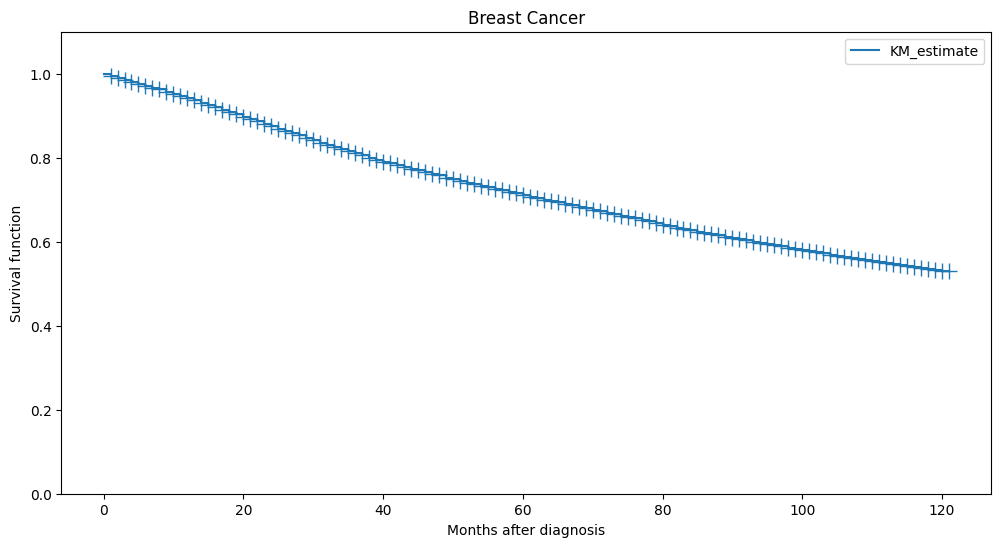

In [ ]:
# Kaplan-Meier Survival Curve Plot
# Extract event (E) and time (T) data from the test set
E = (df_teste.obito_geral == 1)  # Event indicator (obito_geral = 1 means event occurred)
T = df_teste.meses_diag  # Time to event (months since diagnosis)

title = f'Breast Cancer'  # Set the plot title

kmf = KaplanMeierFitter()  # Initialize the Kaplan-Meier fitter

fig = plt.figure(figsize=(12, 6))  # Create the plot figure
ax = plt.subplot(111)  # Create the axes for the plot

# Fit and plot the Kaplan-Meier survival curve
ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True)  # Fit the model, plot the curve, show censoring marks
ax.set_title(title)  # Set the plot title
ax.set_xlabel('Months after diagnosis')  # Set the x-axis label
ax.set_ylabel('Survival function')  # Set the y-axis label
plt.ylim([0, 1.1])  # Set y-axis limits
plt.show()  # Display the plot

In [ ]:
# Survival at 1, 3, 5, 7, and 10 Years
# Access survival probabilities at specific time points (12, 36, 60, 84, and 120 months)
kmf.survival_function_.iloc[[12, 36, 60, 84, 120]]

,KM_estimate
timeline,
12.0,0.942243
36.0,0.811058
60.0,0.710840
84.0,0.627515
120.0,0.529981


## **Machine Learning Survival**

### **Data preparation for survival models**

In [ ]:
# Reading Training Data
df_treino = pd.read_csv('mama_treino.csv')  # Load the training data from the CSV file
print(df_treino.shape)  # Print the dimensions of the training DataFrame
df_treino.head(3)  # Display the first 3 rows of the training DataFrame

(113381, 51)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,ECGRUP,...,PRESENCA_REC,PRESENCA_META,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10,meses_diag,obito_geral
0,275484,9,63,3518701,2,2,C508,85003,IIA,II,...,0,0,0,1,0,0,0,0,16,0
1,21636,2,58,3527405,2,1,C504,85003,IIA,II,...,0,0,0,1,1,0,0,0,47,1
2,22950,2,40,3540002,2,2,C502,85003,IIIB,III,...,0,0,0,1,1,1,1,0,98,0


In [ ]:
# Reading Test Data
df_teste = pd.read_csv('mama_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3)  # Display the first 3 rows of the test DataFrame

(28346, 51)


,INSTITU,ESCOLARI,IDADE,IBGE,CATEATEND,DIAGPREV,TOPO,MORFO,EC,ECGRUP,...,PRESENCA_REC,PRESENCA_META,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,sobrevida_ano7,sobrevida_ano10,meses_diag,obito_geral
0,3,1,38,3530805,9,1,C509,85003,IIA,II,...,0,0,0,1,1,1,1,1,121,0
1,20737,9,38,3506102,9,1,C509,85003,IIIB,III,...,1,0,1,1,1,1,0,0,80,1
2,21636,4,62,3510203,2,1,C508,85003,IA,I,...,0,0,0,1,1,1,0,0,70,0


In [ ]:
# Exclusion of the row where ULTDIAG was negative
df_treino = df_treino[df_treino.ULTIDIAG >= 0]
df_treino.shape

(113380, 51)

In [ ]:
# Y train and test for survival data (Death, Months from Diagnosis)
y_train = Surv.from_arrays(df_treino.obito_geral, df_treino.meses_diag)  # Create survival data for training set
y_test = Surv.from_arrays(df_teste.obito_geral, df_teste.meses_diag)  # Create survival data for test set

In [ ]:
# X train and test after removing unnecessary columns, including Death and Months from Diagnosis (which go to the target Y)
list_drop = ['sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'sobrevida_ano7',
             'sobrevida_ano10', 'obito_geral', 'obito_cancer', 'meses_diag',
             'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO', 'HORMONIO',
             'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
             'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
             'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST', 'RRAS_INST',
             'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META', 'PRESENCA_REC']

X_train = df_treino.drop(list_drop, axis=1)  # Remove specified columns from the training dataset

X_test = df_teste.drop(list_drop, axis=1)  # Remove specified columns from the test dataset

In [ ]:
# Preprocessing of Training and Test data
X_train, X_test, feat_cols, enc, norm = preprocessing(X_train, X_test,
                                                      norm_name='StandardScaler',  # Specify normalization method
                                                      return_enc_norm=True,  # Return encoder and normalizer objects
                                                      random_state=seed)  # Set random state for reproducibility

# Display the shapes of the processed training and test datasets
X_train.shape, X_test.shape

((113380, 16), (28346, 16))

In [ ]:
# Features columns
feat_cols

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV', 'TOPO',
       'MORFO', 'EC', 'ANODIAG', 'DRS', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'TRATCONS_CAT', 'DIAGTRAT_CAT'],
      dtype='object')

### **Random Survival Forest**

#### **Base Model**

In [ ]:
# RSF (Random Survival Forest) Model
rsf = RandomSurvivalForest(max_depth=10, n_jobs=-1, random_state=seed)  # Initialize the RSF model with a max depth of 10
rsf.fit(X_train, y_train)  # Train the model using the training data

# Calculate the C-index for the test dataset
c_index_base = rsf.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_base}')
print(f'C-Index Train: {rsf.score(X_train, y_train)}')

C-Index Test: 0.7748475238564727
C-Index Train: 0.7834631401755765


C-Index IPCW Test: 0.7487719755683928
C-Index IPCW Train: 0.7575131609760349

Integrated Brier Score (IBS): 0.13487291724697767

Brier Score:
    > 1 year = 0.04213831734218388
    > 3 years = 0.1151038824296638
    > 5 years = 0.15244080669100582



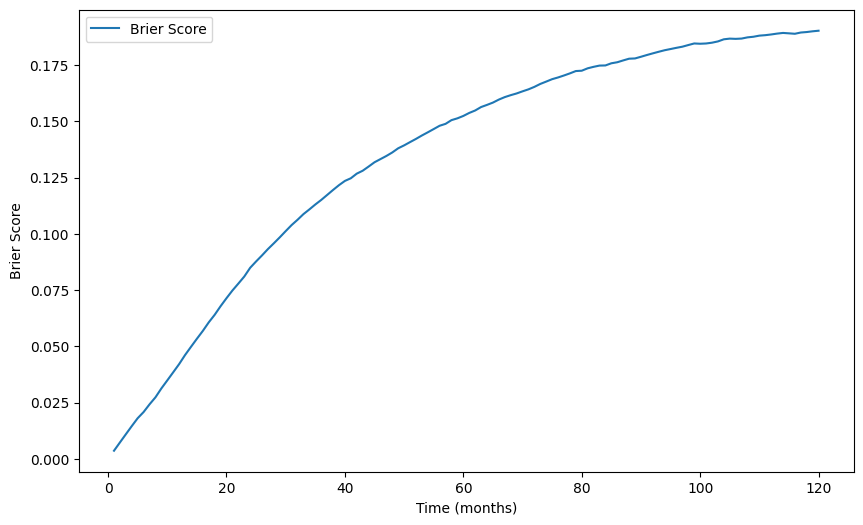

In [ ]:
# C-Index IPCW and Brier Score
c_index_ipcw_brier_score(rsf, X_train, y_train, X_test, y_test)  # Compute and evaluate the IPCW C-index and Brier Score

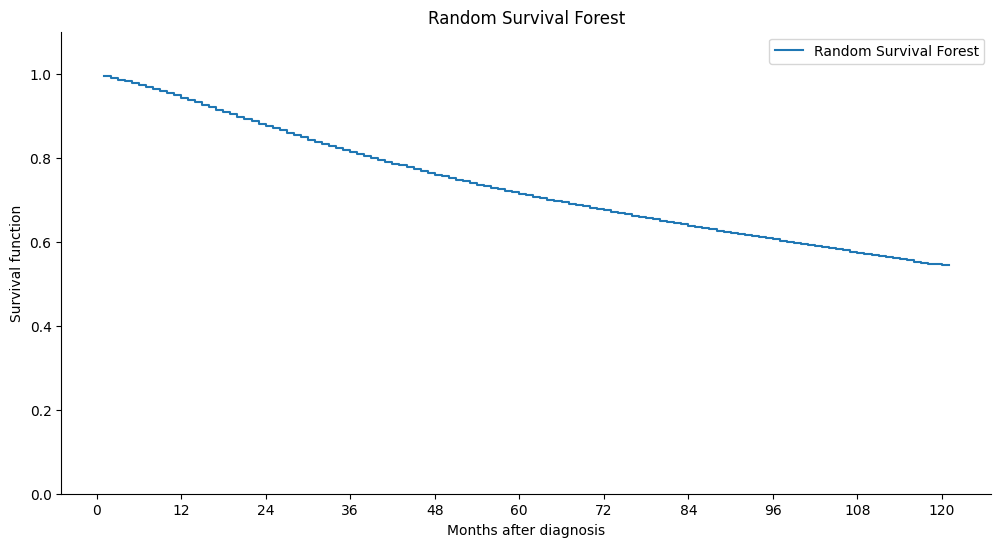

In [ ]:
# Survival prediction (Probability)
surv_rsf = rsf.predict_survival_function(X_test, return_array=True)  # Predict survival probabilities for the test set
surv_rsf_mean = surv_rsf.mean(axis=0)  # Compute the mean survival probability across samples

# Plot the predicted survival curve
name = 'Random Survival Forest'

plot_survival_curve(rsf.unique_times_, surv_rsf_mean, name=name)  # Generate and display the survival curve

In [ ]:
# Survival probability at 12, 36, 60, 84 and 120 months
print(f'12 months: {surv_rsf_mean[12]}')  # Print survival probability at 12 months
print(f'36 months: {surv_rsf_mean[36]}')  # Print survival probability at 36 months
print(f'60 months: {surv_rsf_mean[60]}')  # Print survival probability at 60 months
print(f'84 months: {surv_rsf_mean[84]}')  # Print survival probability at 84 months
print(f'120 months: {surv_rsf_mean[120]}')  # Print survival probability at 120 months

12 months: 0.9373827257831345
36 months: 0.80890047953489
60 months: 0.7101332429955004
84 months: 0.6354573730809743
120 months: 0.543756016106588


#### **Optuna**

In [ ]:
# Optuna number of trials
n_trials = 150

In [ ]:
# Folds for cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=seed)  # Create a 10-fold cross-validation strategy

# Function to compute the C-index for a given estimator
def c_index(estimator, X, y):
    cindex = estimator.score(X, y)  # Compute the C-index score
    return cindex

# Objective function for hyperparameter optimization
def objective(trial):
    # Define hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of trees in the forest
    max_depth = trial.suggest_int('max_depth', 4, 12)  # Maximum depth of each tree
    min_samples_split = trial.suggest_int('min_samples_split', 3, 12)  # Min samples required to split a node
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 3, 12)  # Min samples required at a leaf node
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.75, 1.0])  # Feature selection strategy
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])  # Whether to use bootstrap sampling

    # Create and train the model with the suggested hyperparameters
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=seed,
        n_jobs=-1
    )

    # Perform cross-validation and return the mean C-index score
    return cross_val_score(rsf, X_train, y_train, cv=kf, scoring=c_index).mean()

**RandomSampler**

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'mama_opt_rsf_rand.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed=seed),
                                study_name='RSF_RandomSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 20.7 ms, sys: 0 ns, total: 20.7 ms
Wall time: 20.6 ms


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 111, 'max_depth': 12, 'min_samples_split': 9, 'min_samples_leaf': 11, 'max_features': 'log2', 'bootstrap': True}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_rand = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_rand.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_rand = rsf_rand.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {rsf_rand.score(X_train, y_train)}')

C-Index Test: 0.778202871182139
C-Index Train: 0.7919179015729999


**TPESampler**

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'mama_opt_rsf_tpe.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
                                study_name='RSF_TPESampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 26.1 ms, sys: 2.08 ms, total: 28.2 ms
Wall time: 70.5 ms


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 149, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_tpe = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_tpe.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_tpe = rsf_tpe.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {rsf_tpe.score(X_train, y_train)}')

C-Index Test: 0.778357930378509
C-Index Train: 0.7926052001841516


**CmaEsSampler**

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'mama_opt_rsf_cma.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
                                study_name='RSF_CmaEsSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 24.4 ms, sys: 0 ns, total: 24.4 ms
Wall time: 28.7 ms


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 114, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': False}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_cma = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_cma.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_cma = rsf_cma.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_cma}')
print(f'C-index Train: {rsf_cma.score(X_train, y_train)}')

C-Index Test: 0.7779287951043174
C-index Train: 0.7948910873707159


#### **Best Random Survival Forest Model**

In [ ]:
# Best RSF model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for different models
models = [rsf, rsf_rand, rsf_tpe, rsf_cma]  # List of the corresponding models

# Find the index of the model with the highest C-index score
id_best_score = scores.index(max(scores))
best = models[id_best_score]  # Select the model with the best score

# Print the best model
print(best)

RandomSurvivalForest(max_depth=12, min_samples_leaf=8, min_samples_split=7,
                     n_estimators=149, random_state=1)


C-Index Test: 0.778357930378509
C-Index Train: 0.7926052001841516

C-Index IPCW Test: 0.7525375752096892
C-Index IPCW Train: 0.7677734550597116

Integrated Brier Score (IBS): 0.13318994214915997

Brier Score:
    > 1 year = 0.041941937599272235
    > 3 years = 0.11393887106831511
    > 5 years = 0.15057204690756884



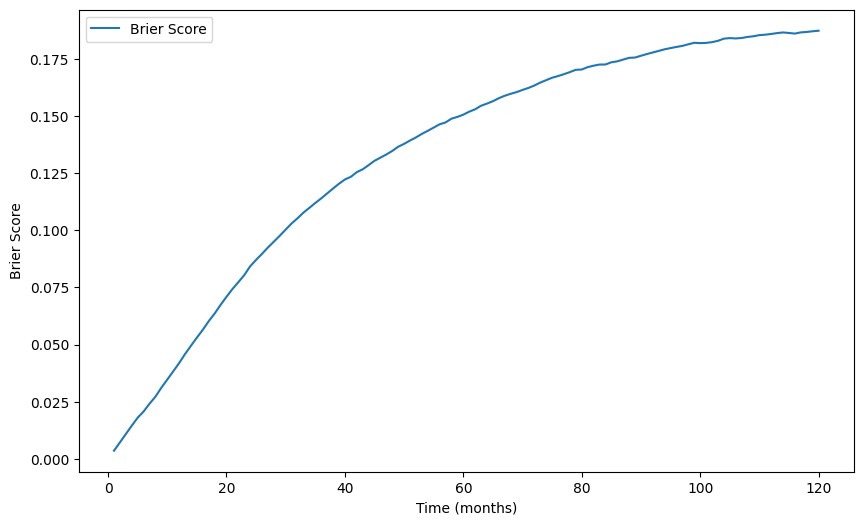

In [ ]:
# Metrics of the best RSF model
final_c_index = best.score(X_test, y_test)  # Compute the final C-index for the test dataset

# Print the C-index for both test and training datasets
print(f'C-Index Test: {final_c_index}')
print(f'C-Index Train: {best.score(X_train, y_train)}\n')

# Compute and display the IPCW C-index and Brier Score for the best model
c_index_ipcw_brier_score(best, X_train, y_train, X_test, y_test)

In [ ]:
# Best features by permutation importance
calculate_permutation_importance(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
EC,0.191229,0.002246
IDADE,0.028248,0.000925
CATEATEND,0.008051,0.000586
DIAGTRAT_CAT,0.004607,0.000370
TRATCONS_CAT,0.003316,0.000354
INSTITU,0.003248,0.000184
ESCOLARI,0.002667,0.000259
TOPO,0.002639,0.000336
ANODIAG,0.002056,0.000214
IBGEATEN,0.001990,0.000245


PermutationExplainer explainer: 28347it [8:52:41,  1.13s/it]                             


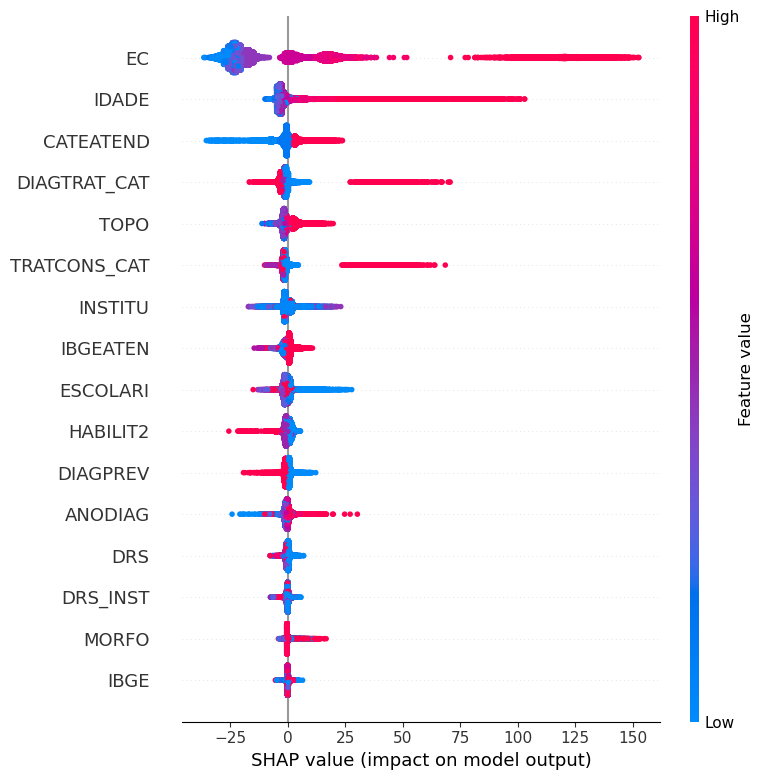

In [ ]:
# Best features by SHAP
explainer = shap.Explainer(best.predict, X_train, seed=seed,  # Create a SHAP explainer for the best model
                           output_names=feat_cols,  # Specify the feature names
                           n_jobs=-1)  # Use multiple jobs for parallel computation

shap_values = explainer(X_test)  # Calculate SHAP values for the test set

# Plot the SHAP summary plot to visualize feature importance
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

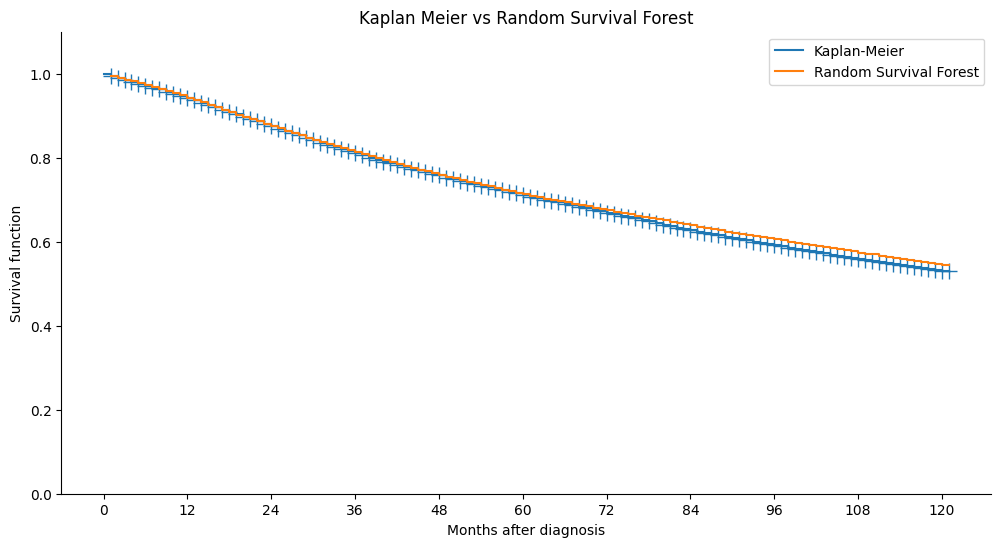

In [ ]:
# Comparison of survival curves
name = 'Random Survival Forest'  # Name of the model to be displayed on the plot

# Predict survival functions for the test set and compute the mean survival function
surv_rsf = best.predict_survival_function(X_test, return_array=True)
surv_rsf_mean = surv_rsf.mean(axis=0)  # Compute the mean survival function across all samples

# Plot the survival curve and compare with Kaplan-Meier (KM) estimates
plot_survival_curve(best.unique_times_, surv_rsf_mean,
                    name=name, compare_km=True, test_df=df_teste)  # Plot the survival curve and compare with the test dataset

### **Gradient Boosting Survival**

#### **Base Model**

In [ ]:
%%time
# GBS (Gradient Boosting Survival) Model
gb = GradientBoostingSurvivalAnalysis(n_estimators=100, max_depth=7,  # Initialize the GBS model with 100 estimators and a max depth of 7
                                      random_state=seed)  # Set the random state for reproducibility
gb.fit(X_train, y_train)  # Train the model using the training data

# Compute the C-index for the test dataset
c_index_base = gb.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_base}')
print(f'C-Index Train: {gb.score(X_train, y_train)}')

C-Index Test: 0.7762732844849476
C-Index Train: 0.7861049546916856
CPU times: user 6h 58min 6s, sys: 104 ms, total: 6h 58min 6s
Wall time: 10h 8min 23s


C-Index IPCW Teste: 0.7505613215295427
C-Index IPCW Treino: 0.7616195688699355

Integrated Brier Score (IBS): 0.1338530911904448

Brier Score:
    > 1 ano = 0.04316587290879048
    > 3 anos = 0.1152299515517703
    > 5 anos = 0.15127428530219028



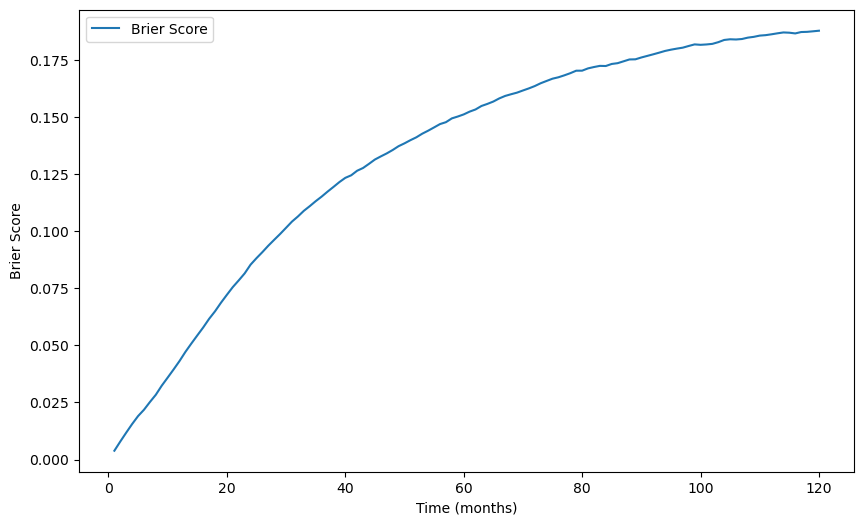

In [ ]:
# C-Index IPCW and Brier Score
c_index_ipcw_brier_score(gb, X_train, y_train, X_test, y_test)  # Compute and evaluate the IPCW C-index and Brier Score for the GBS model

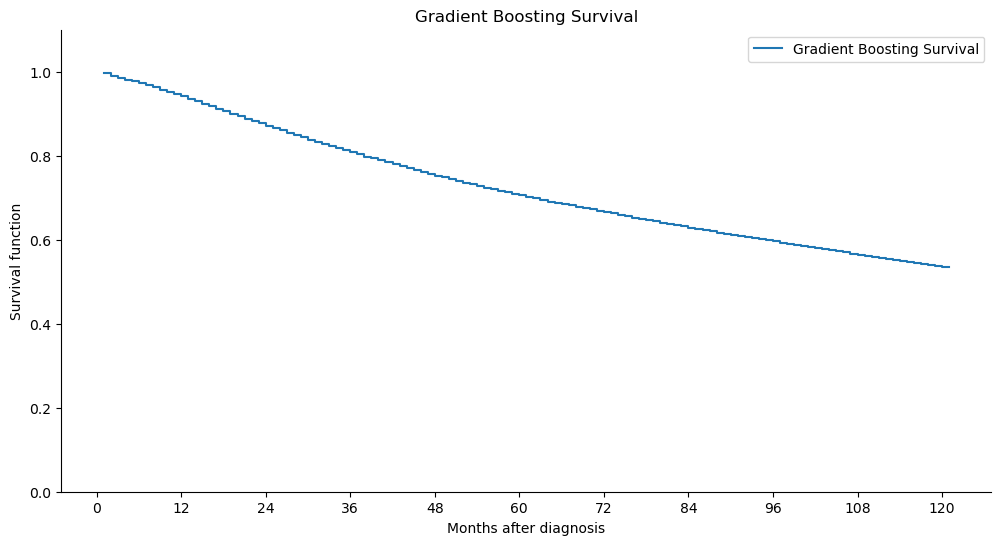

In [ ]:
# Survival function (Probability)
surv_gb = gb.predict_survival_function(X_test, return_array=True)  # Predict survival probabilities for the test set
surv_gb_mean = surv_gb.mean(axis=0)  # Compute the mean survival probability across samples

# Plot the predicted survival curve
name = 'Gradient Boosting Survival'

plot_survival_curve(gb.unique_times_, surv_gb_mean, name=name)  # Generate and display the survival curve

In [ ]:
# Survival probability at 12, 36, 60, 84, and 120 months
print(f'12 months: {surv_gb_mean[12]}')  # Print survival probability at 12 months
print(f'36 months: {surv_gb_mean[36]}')  # Print survival probability at 36 months
print(f'60 months: {surv_gb_mean[60]}')  # Print survival probability at 60 months
print(f'84 months: {surv_gb_mean[60]}')  # Print survival probability at 84 months
print(f'120 months: {surv_gb_mean[60]}')  # Print survival probability at 120 months

12 months: 0.9352480353111421
36 months: 0.8031280405896511
60 months: 0.7015217522860522
84 months: 0.7015217522860522
120 months: 0.7015217522860522


#### **Optuna**

In [ ]:
# Optuna number of trials
n_trials = 100

In [ ]:
# Folds for cross-validation
kf = KFold(10, shuffle=True, random_state=seed)  # Create a 10-fold cross-validation strategy

# Function to compute the C-index for a given estimator
def c_index(estimator, X, y):
    cindex = estimator.score(X, y)  # Compute the C-index score
    return cindex

# Objective function for hyperparameter optimization
def objective(trial):
    # Define hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of boosting stages (trees)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, step=0.01)  # Learning rate for gradient boosting
    max_depth = trial.suggest_int('max_depth', 4, 8)  # Maximum depth of the individual trees
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)  # Minimum number of samples required to split an internal node
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10)  # Minimum number of samples required to be at a leaf node
    subsample = trial.suggest_float('subsample', 0.5, 1.0, step=0.1)  # Fraction of samples used for fitting each tree
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.75, 1.0])  # Feature selection strategy for each tree

    # Create and train the model with the suggested hyperparameters
    gbsa = GradientBoostingSurvivalAnalysis(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        max_features=max_features,
        random_state=seed
    )

    # Perform cross-validation and return the mean C-index score
    return cross_val_score(gbsa, X_train, y_train, cv=kf, scoring=c_index).mean()

**RandomSampler**

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'mama_opt_gbs_rand.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
                                study_name='GBS_RandomSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 10.3 ms, sys: 0 ns, total: 10.3 ms
Wall time: 11.4 ms


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best parameters after optimization

Best parameters: {'n_estimators': 102, 'learning_rate': 0.18000000000000002, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 3, 'subsample': 1.0, 'max_features': 0.5}


In [ ]:
%%time
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
gbsa_rand = GradientBoostingSurvivalAnalysis(**best_params, random_state=seed)  # Initialize the GBS model with the best parameters
gbsa_rand.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_rand = gbsa_rand.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {gbsa_rand.score(X_train, y_train)}')

C-Index Test: 0.7807230081074165
C-Index Train: 0.8023241636147953
CPU times: user 7h 11min 43s, sys: 244 ms, total: 7h 11min 43s
Wall time: 8h 27min 28s


**TPESampler**

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'mama_opt_gbs_tpe.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
                                study_name='GBS_TPESampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 8.99 ms, sys: 985 µs, total: 9.98 ms
Wall time: 11.4 ms


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best parameters after optimization

Best parameters: {'n_estimators': 150, 'learning_rate': 0.18000000000000002, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 2, 'subsample': 0.8, 'max_features': 'sqrt'}


In [ ]:
%%time
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
gbsa_tpe = GradientBoostingSurvivalAnalysis(**best_params, random_state=seed)  # Initialize the GBS model with the best parameters
gbsa_tpe.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_tpe = gbsa_tpe.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {gbsa_tpe.score(X_train, y_train)}')

C-Index Test: 0.7828013712282289
C-Index Train: 0.8071260428007625
CPU times: user 8h 27min 26s, sys: 639 ms, total: 8h 27min 27s
Wall time: 8h 29min 12s


**CmaEsSampler**

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'mama_opt_gbs_cma.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
                                study_name='GBS_CmaEsSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

CPU times: user 7.32 ms, sys: 2.97 ms, total: 10.3 ms
Wall time: 11.9 ms


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best parameters after optimization

Best parameters: {'n_estimators': 119, 'learning_rate': 0.17, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 8, 'subsample': 0.7, 'max_features': 'sqrt'}


In [ ]:
%%time
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
gbsa_cma = GradientBoostingSurvivalAnalysis(**best_params, random_state=seed)  # Initialize the GBS model with the best parameters
gbsa_cma.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_cma = gbsa_cma.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_cma}')
print(f'C-Index Train: {gbsa_cma.score(X_train, y_train)}')

C-Index Test: 0.7809947517134574
C-Index Train: 0.7928526633383001
CPU times: user 5h 32min 14s, sys: 456 ms, total: 5h 32min 14s
Wall time: 5h 33min 7s


#### **Best Gradient Boosting Survival Model**

In [ ]:
# Best GBS model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for each model
models = [gb, gbsa_rand, gbsa_tpe, gbsa_cma]  # List of corresponding models

id_best_score = scores.index(max(scores))  # Find the index of the model with the highest C-index score
best = models[id_best_score]  # Select the best model based on the highest score

print(best)  # Print the best model

GradientBoostingSurvivalAnalysis(learning_rate=0.18000000000000002, max_depth=8,
                                 max_features='sqrt', min_samples_leaf=2,
                                 min_samples_split=8, n_estimators=150,
                                 random_state=1, subsample=0.8)


C-Index Test: 0.7828013712282289
C-Index Train: 0.8071260428007625

C-Index IPCW Teste: 0.7573602424634319
C-Index IPCW Treino: 0.7847262783076276

Integrated Brier Score (IBS): 0.1319265145775951

Brier Score:
    > 1 ano = 0.04245988570305721
    > 3 anos = 0.11355323739143594
    > 5 anos = 0.14895227945961717



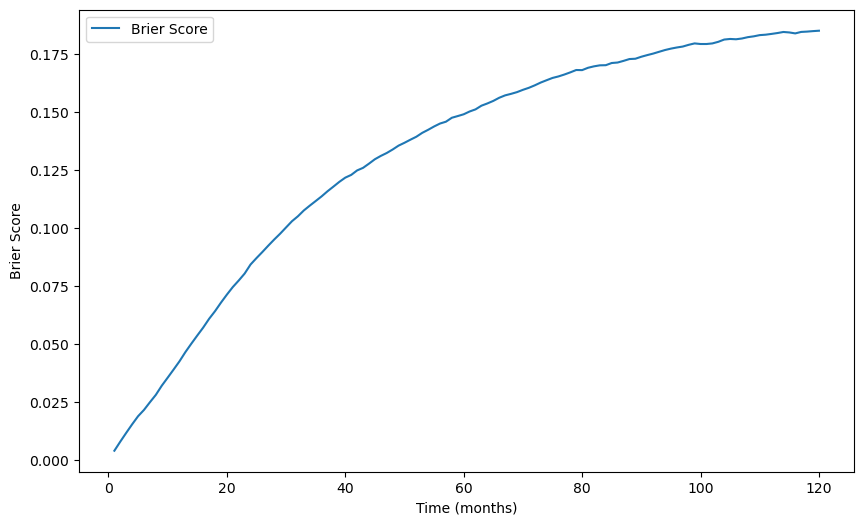

In [ ]:
# Metrics of the best GBS model
final_c_index = best.score(X_test, y_test)  # Compute the C-index for the best model on the test dataset

print(f'C-Index Test: {final_c_index}')  # Print the C-index for the test set
print(f'C-Index Train: {best.score(X_train, y_train)}\n')  # Print the C-index for the training set

# Calculate and print the IPCW and Brier score for the best model
c_index_ipcw_brier_score(best, X_train, y_train, X_test, y_test)

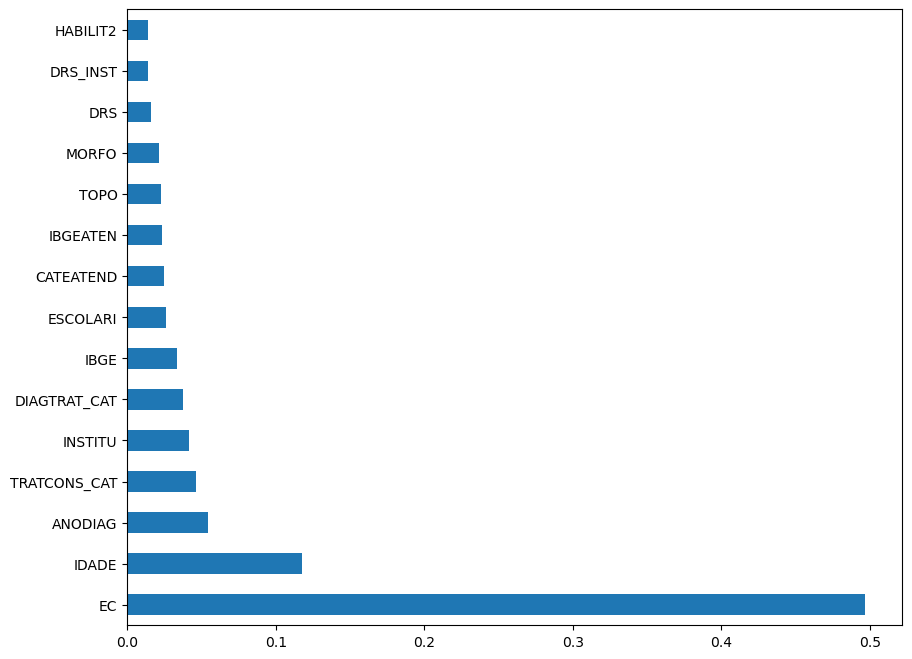

In [ ]:
# Feature Importances
feat_import = pd.Series(best.feature_importances_, index=feat_cols)  # Create a pandas Series with feature importances
feat_import.nlargest(15).plot(kind='barh', figsize=(10, 8))  # Plot the top 15 most important features as a horizontal bar chart
plt.show()  # Display the plot

In [ ]:
# Best features by permutation importance
calculate_permutation_importance(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
EC,0.194122,0.002251
IDADE,0.028559,0.000984
CATEATEND,0.014867,0.000790
ANODIAG,0.007539,0.000670
INSTITU,0.005720,0.000308
IBGEATEN,0.003785,0.000419
TRATCONS_CAT,0.003508,0.000376
ESCOLARI,0.003112,0.000294
DIAGTRAT_CAT,0.003104,0.000304
TOPO,0.002512,0.000382


PermutationExplainer explainer: 28347it [59:30,  7.92it/s]                           


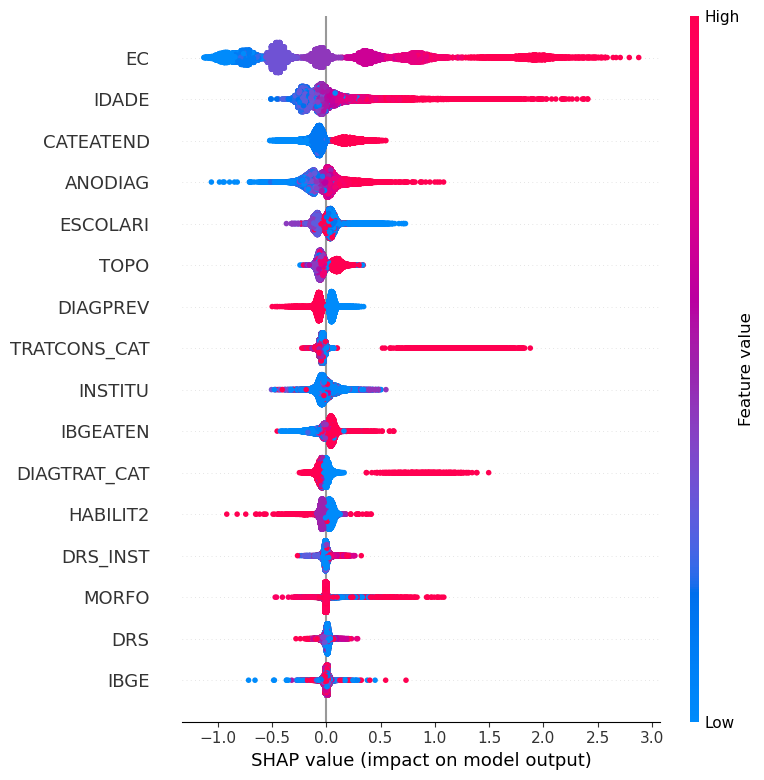

In [ ]:
# Best features by SHAP
explainer = shap.Explainer(best.predict, X_train, seed=seed,  # Create a SHAP explainer for the best model
                           output_names=feat_cols,  # Specify the feature names
                           n_jobs=-1)  # Use multiple jobs for parallel computation

shap_values = explainer(X_test)  # Calculate SHAP values for the test set

# Plot the SHAP summary plot to visualize feature importance
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

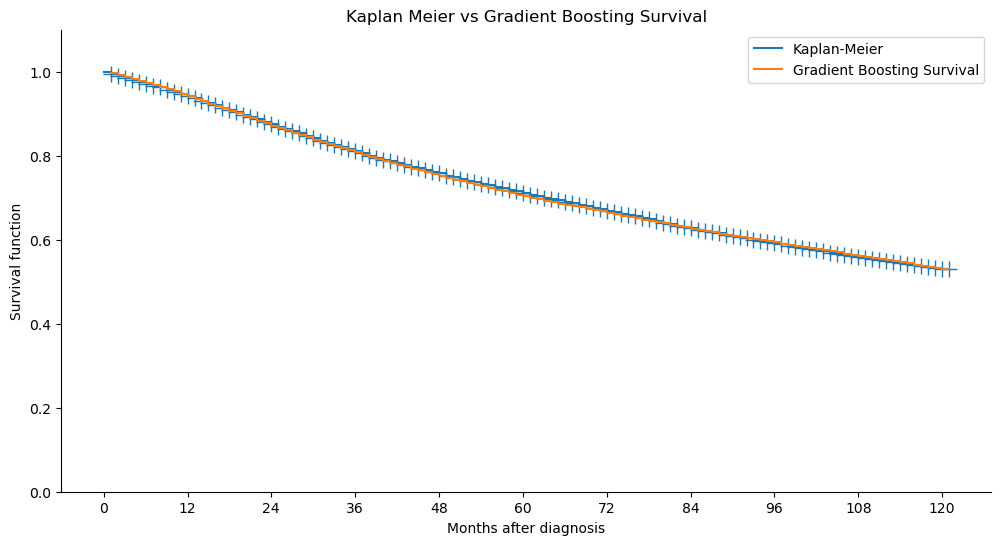

In [ ]:
# Comparison of survival curves
name = 'Gradient Boosting Survival'  # Set the name for the survival model

surv_gbs = best.predict_survival_function(X_test, return_array=True)  # Predict the survival function for the test set
surv_gbs_mean = surv_gbs.mean(axis=0)  # Compute the mean survival probability across the predictions

# Plot the survival curve and compare with the Kaplan-Meier curve
plot_survival_curve(best.unique_times_, surv_gbs_mean,
                    name=name, compare_km=True, test_df=df_teste)  # Visualize the survival curve with the comparison to the Kaplan-Meier estimate

### **Survival SVM**

#### **Base Model**

In [ ]:
# SurvivalSVM Model
ssvm = FastSurvivalSVM(random_state=seed)  # Initialize the FastSurvivalSVM model with a fixed random state

ssvm.fit(X_train, y_train)  # Train the model on the training data

c_index_base = ssvm.score(X_test, y_test)  # Calculate the C-index on the test dataset

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_base}')
print(f'C-Index Train: {ssvm.score(X_train, y_train)}')

C-Index Test: 0.7573846603956363
C-Index Train: 0.7572716258541637


In [ ]:
# C-Index IPCW
surv_risks = ssvm.predict(X_test)  # Predict survival risks for the test dataset
surv_risks_train = ssvm.predict(X_train)  # Predict survival risks for the training dataset

# Calculate the IPCW C-index for both test and training datasets
c_index_ipcw = concordance_index_ipcw(y_train, y_test, surv_risks)
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, surv_risks_train)

# Print the IPCW C-index for both test and training datasets
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')

C-Index IPCW Test: 0.7301389813515529
C-Index IPCW Train: 0.7312276433761006


#### **Optuna**

In [ ]:
# Optuna number of trials
n_trials = 150

In [ ]:
# Folds for cross-validation
kf = KFold(10, shuffle=True, random_state=seed)  # Create a KFold cross-validator with 10 splits, shuffling, and a fixed random seed

def c_index(estimator, X, y):
    cindex = estimator.score(X, y)  # Compute the C-index of the estimator on the dataset
    return cindex

def objective(trial):
    # Define hyperparameters to be optimized
    param = {
        'alpha': trial.suggest_categorical('alpha', [1e-3, 1e-2, 1e-1, 1, 10]),  # Suggest different values for the alpha regularization parameter
        'rank_ratio': trial.suggest_float('rank_ratio', 0.1, 1.0, step=0.05),  # Suggest a value for the rank ratio
        'tol': trial.suggest_categorical('tol', [1e-5, 1e-4, 1e-3, 1e-2]),  # Suggest tolerance values for convergence
    }

    # Train the model with the suggested parameters
    ssvm = FastSurvivalSVM(**param, random_state=seed)

    return cross_val_score(ssvm, X_train, y_train, cv=kf, scoring=c_index).mean()  # Return the mean cross-validated C-index score

**RandomSampler**

In [ ]:
%%time
# Filename for saving the pickle study
pickle_filename = 'mama_opt_svm_rand.pkl'

# Load the existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)  # Load the study from the pickle file if it exists
else:
    study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),  # Create a new Optuna study
                                study_name='SSVM_RandomSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in blocks
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)  # Optimize the objective function with 50 trials at a time
    completed_trials = len(study.trials)
    print(f"\nCompleted trials: {completed_trials}/{n_trials}")

    # Save the study after each block
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)  # Save the study object to a pickle file

CPU times: user 16.3 ms, sys: 13 µs, total: 16.4 ms
Wall time: 16.4 ms


In [ ]:
# Display the best hyperparameters found
print('Best parameters:', study.best_params)

Best parameters: {'alpha': 0.001, 'rank_ratio': 0.7000000000000001, 'tol': 0.001}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params
ssvm_rand = FastSurvivalSVM(**best_params, random_state=seed)  # Initialize the model with the best parameters
ssvm_rand.fit(X_train, y_train)  # Train the model on the training data

c_index_rand = ssvm_rand.score(X_test, y_test)  # Compute the C-index on the test data

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {ssvm_rand.score(X_train, y_train)}')

C-Index Test: 0.7573787547108936
C-Index Train: 0.7572736237476906


**TPESampler**

In [ ]:
%%time
# Filename for saving the pickle study
pickle_filename = 'mama_opt_svm_tpe.pkl'

# Load the existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)  # Load the study from the pickle file if it exists
else:
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),  # Create a new Optuna study using TPE sampler
                                study_name='SSVM_TPESampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in blocks
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)  # Optimize the objective function with 50 trials at a time
    completed_trials = len(study.trials)
    print(f"\nCompleted trials: {completed_trials}/{n_trials}")

    # Save the study after each block
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)  # Save the study object to a pickle file

CPU times: user 21.2 ms, sys: 19 µs, total: 21.2 ms
Wall time: 24.7 ms


In [ ]:
# Display the best hyperparameters found
print('Best parameters:', study.best_params)

Best parameters: {'alpha': 0.1, 'rank_ratio': 0.7000000000000001, 'tol': 0.001}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params
ssvm_tpe = FastSurvivalSVM(**best_params, random_state=seed)  # Initialize the model with the best parameters
ssvm_tpe.fit(X_train, y_train)  # Train the model on the training data

c_index_tpe = ssvm_tpe.score(X_test, y_test)  # Compute the C-index on the test data

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {ssvm_tpe.score(X_train, y_train)}')

C-Index Test: 0.7573787425467643
C-Index Train: 0.7572736214805773


**CmaEsSampler**

In [ ]:
%%time
# Filename for saving the pickle study
pickle_filename = 'mama_opt_svm_cma.pkl'

# Load the existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)  # Load the study from the pickle file if it exists
else:
    study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),  # Create a new Optuna study using CMA-ES sampler
                                study_name='SSVM_CmaEsSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in blocks
while completed_trials < n_trials:
    study.optimize(objective, n_trials=50, n_jobs=-1)  # Optimize the objective function with 50 trials at a time
    completed_trials = len(study.trials)
    print(f"\nCompleted trials: {completed_trials}/{n_trials}")

    # Save the study after each block
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)  # Save the study object to a pickle file

CPU times: user 21.7 ms, sys: 0 ns, total: 21.7 ms
Wall time: 62.5 ms


In [ ]:
# Display the best hyperparameters found
print('Best parameters:', study.best_params)

Best parameters: {'alpha': 10, 'rank_ratio': 0.7000000000000001, 'tol': 0.001}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params
ssvm_cma = FastSurvivalSVM(**best_params, random_state=seed)  # Initialize the model with the best parameters
ssvm_cma.fit(X_train, y_train)  # Train the model on the training data

c_index_cma = ssvm_cma.score(X_test, y_test)  # Compute the C-index on the test data

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_cma}')
print(f'C-Index Train: {ssvm_cma.score(X_train, y_train)}')

C-Index Test: 0.7573787425467643
C-Index Train: 0.7572736214805773


#### **Best Survival SVM Model**

In [ ]:
# Best SSVM model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for different models
models = [ssvm, ssvm_rand, ssvm_tpe, ssvm_cma]  # List of corresponding SSVM models

id_best_score = scores.index(max(scores))  # Identify the index of the model with the highest C-index score
best = models[id_best_score]  # Select the model with the best performance

print(best)  # Print the best model

FastSurvivalSVM(optimizer='avltree', random_state=1)


In [ ]:
# C-Index Calculation
print('C-Index')
print(f'> Test: {best.score(X_test, y_test)}')  # Calculate and print the C-index for the test set
print(f'> Train: {best.score(X_train, y_train)}')  # Calculate and print the C-index for the training set

# C-Index IPCW Calculation
surv_risks = best.predict(X_test)  # Predict survival risks for the test set
surv_risks_train = best.predict(X_train)  # Predict survival risks for the training set

# Compute IPCW C-index for test and train sets
c_index_ipcw = concordance_index_ipcw(y_train, y_test, surv_risks)  # IPCW C-index for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, surv_risks_train)  # IPCW C-index for the train set

print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')  # Print the IPCW C-index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print the IPCW C-index for the training set

C-Index
> Test: 0.7573846603956363
> Train: 0.7572716258541637

C-Index IPCW
> Test: 0.7301389813515529
> Train: 0.7312276433761006


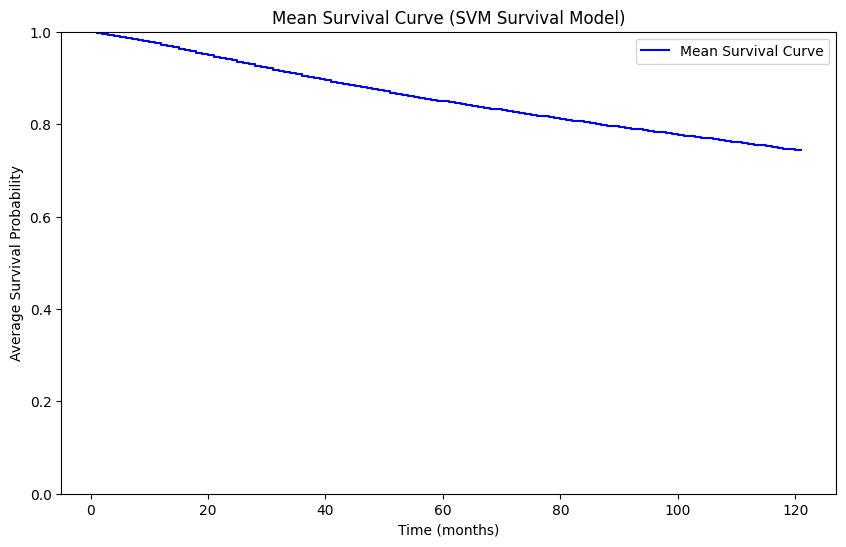

In [ ]:
# Normalize the survival risks (scale them between 0 and 1)
surv_risks_normalized = (surv_risks - np.min(surv_risks)) / (np.max(surv_risks) - np.min(surv_risks))

# Estimate the baseline survival function using Kaplan-Meier on the training data
time, survival_prob = kaplan_meier_estimator(y_train["event"], y_train["time"])

# Calculate the survival probabilities for all individuals
survival_probabilities = predict_survival_probability(surv_risks_normalized, survival_prob, time)

# Calculate the mean survival probability across all individuals
mean_survival_probability = survival_probabilities.mean(axis=0)  # Now (n_time,)

# Plot the mean survival curve
plt.figure(figsize=(10, 6))
plt.step(time, mean_survival_probability, where="post", color="blue", label="Mean Survival Curve")

# Configure the plot
plt.title("Mean Survival Curve (SVM Survival Model)")
plt.xlabel("Time (months)")
plt.ylabel("Mean Survival Probability")
plt.ylim([0, 1.0])  # Set y-axis limit to 0-1
plt.legend()
plt.show()

Brier Score at 12 months: 0.0542
Brier Score at 36 months: 0.1523
Brier Score at 60 months: 0.2059
Brier Score at 84 months: 0.2393
Brier Score at 120 months: 0.2636

Integrated Brier Score (IBS): 0.1825


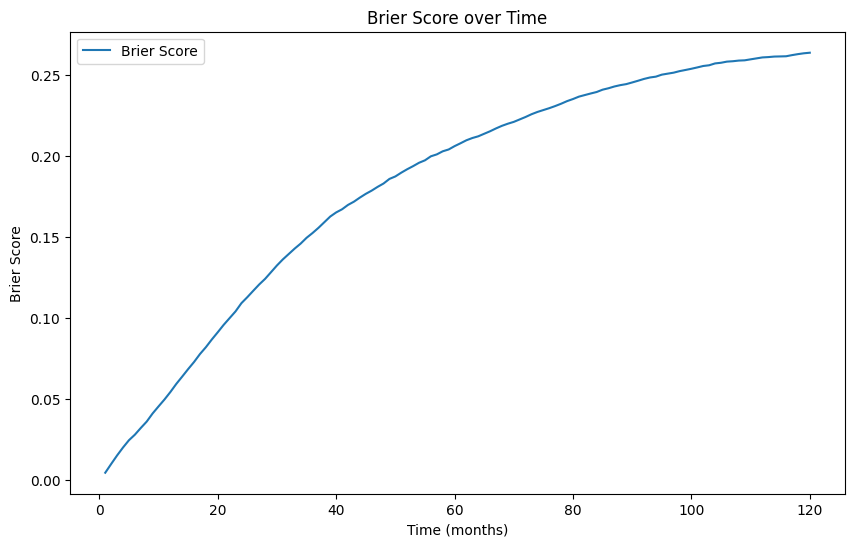

In [ ]:
# Time points for the calculation
time_points = np.arange(1, 121, 1)  # From 1 to 120 months
specific_time_points = [12, 36, 60, 84, 120]  # Specific time points for analysis

# Ensure alignment of survival probabilities with 'time'
assert survival_probabilities.shape[1] == len(time)

# Adjust probabilities for the desired time points (row by row)
surv_curves = np.array([
    np.interp(time_points, time, survival_probabilities[i, :])
    for i in range(survival_probabilities.shape[0])
])

# Calculate the Brier Score at specific time points
brier_scores_specific = []
for t in specific_time_points:
    # Find the index of the closest time in 'time_points'
    idx = np.abs(time_points - t).argmin()
    prob_surv_t = surv_curves[:, idx]

    # Get the actual observations
    true_values = (y_test['time'] >= t) & (y_test['event'] == 1)

    # Calculate the Brier Score for time t
    brier = brier_score(y_train, y_test, prob_surv_t, [t])
    brier_scores_specific.append(brier[1][0])  # Extract the numeric value

    print(f"Brier Score at {t} months: {brier[1][0]:.4f}")

# Calculate the Brier Score over time for the IBS
brier_scores = brier_score(y_train, y_test, surv_curves, time_points)

# Calculate the Integrated Brier Score (IBS)
time_differences = np.diff(np.hstack([[0], time_points]))
ibs = np.sum(brier_scores[1] * time_differences) / time_points[-1]
print(f"\nIntegrated Brier Score (IBS): {ibs:.4f}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1], label="Brier Score")
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score over Time")
plt.legend()
plt.show()

In [ ]:
# Best features by permutation importance
calculate_permutation_importance(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
EC,0.227604,0.002651
IDADE,0.016284,0.000583
CATEATEND,0.008807,0.000599
ANODIAG,0.002010,0.000347
DIAGPREV,0.001892,0.000170
TOPO,0.001124,0.000175
IBGEATEN,0.000920,0.000124
HABILIT2,0.000732,0.000149
TRATCONS_CAT,0.000628,0.000108
MORFO,0.000470,0.000162


PermutationExplainer explainer: 28347it [09:31, 48.69it/s]


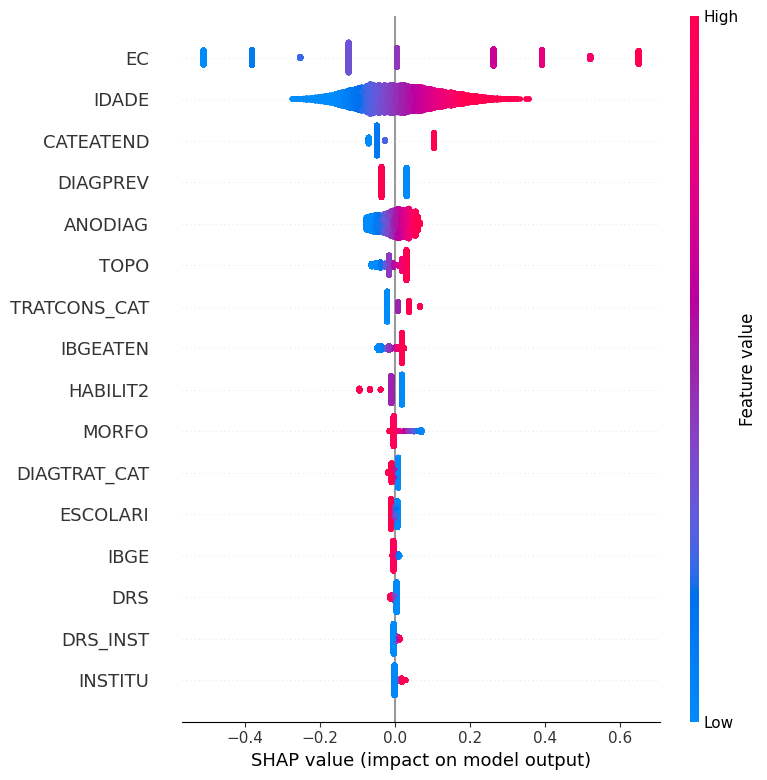

In [ ]:
# Best features by SHAP
explainer = shap.Explainer(best.predict, X_train, seed=seed,  # Create a SHAP explainer for the best model
                           output_names=feat_cols,  # Specify the feature names
                           n_jobs=-1)  # Use multiple jobs for parallel computation

shap_values = explainer(X_test)  # Calculate SHAP values for the test set

# Plot the SHAP summary plot to visualize feature importance
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

### **XGBoost - Cox**

#### **Base Model**

In [ ]:
# XGBoost Model
weights = np.where(y_train['event'], 1.0, 0.1)  # Assigning weights to the training data based on event status (1.0 for events, 0.15 for censored)

dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)  # Prepare the training dataset for XGBoost, including weights and time as the target
dtest = xgb.DMatrix(X_test)  # Prepare the test dataset for prediction

# Training the XGBoost model for survival analysis
params = {
    'objective': 'survival:cox',  # Specify Cox proportional hazards objective for survival analysis
    'eval_metric': 'cox-nloglik',  # Use negative log-likelihood as the evaluation metric
    'max_depth': 5,  # Set the maximum depth of trees
    'seed': seed,  # Set random seed for reproducibility
}
xgboost = xgb.train(params, dtrain, num_boost_round=100)  # Train the XGBoost model with 100 boosting rounds

# Make predictions and calculate C-Index for Test data
y_pred = xgboost.predict(dtest)  # Predict survival times for the test set
c_index_base = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # Calculate C-Index for the test data

# Make predictions and calculate C-Index for Training data
y_pred_train = xgboost.predict(dtrain)  # Predict survival times for the training set
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # Calculate C-Index for the training data

# Display C-Index for Test and Train data
print(f'C-index Test: {c_index_base}')  # Print the C-Index for the test data
print(f'C-index Train: {c_index_train}')  # Print the C-Index for the training data

C-index Test: 0.6992831988828074
C-index Train: 0.7155088150406397


In [ ]:
# C-Index IPCW (Inverse Probability of Censoring Weight)
surv_risks = xgboost.predict(dtest)  # Predict the survival risks for the test set
surv_risks_train = xgboost.predict(dtrain)  # Predict the survival risks for the training set

# Calculate the C-Index IPCW for Test and Train data
c_index_ipcw = concordance_index_ipcw(y_train, y_test, surv_risks)  # Compute the C-Index IPCW for the test data
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, surv_risks_train)  # Compute the C-Index IPCW for the training data

# Display C-Index IPCW for Test and Train data
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')  # Print the C-Index IPCW for the test data
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')  # Print the C-Index IPCW for the training data

C-Index IPCW Test: 0.6863263434582797
C-Index IPCW Train: 0.6993884913317561


#### **Optuna**

In [ ]:
# Optuna number o trials
n_trials = 150

In [ ]:
# Folds for Cross-Validation
kf = KFold(10, shuffle=True, random_state=seed)  # Create 10-fold cross-validation with shuffling

def objective(trial):
    # Define the hyperparameters to be optimized
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # Number of estimators (trees)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, step=0.01),  # Learning rate
        'max_depth': trial.suggest_int('max_depth', 3, 6),  # Maximum depth of trees
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),  # Minimum weight of child nodes
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.05),  # Fraction of data used for training
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.05),  # Fraction of features used per tree
        'reg_alpha': trial.suggest_categorical('reg_alpha', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L1 regularization term
        'reg_lambda': trial.suggest_categorical('reg_lambda', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L2 regularization term
        'objective': 'survival:cox',  # Cox loss function for survival analysis
        'eval_metric': 'cox-nloglik',  # Evaluation metric for Cox model
        'random_state': seed,  # Seed for reproducibility
        'n_jobs': -1,  # Use all available cores for training
    }

    c_index_list = []  # List to store the C-index values from each fold

    # Loop over the folds in cross-validation
    for train_idx, valid_idx in kf.split(X_train):
        try:
            # Split the data into training and validation sets for the current fold
            X_t, X_v = X_train[train_idx], X_train[valid_idx]  # Split features
            y_t, y_v = y_train[train_idx], y_train[valid_idx]  # Split labels

            # Create DMatrix for training and validation (DMatrix is an optimized data structure for XGBoost)
            dtrain = xgb.DMatrix(X_t, label=y_t['time'], weight=np.where(y_t['event'], 1.0, 0.1))  # Set event weights
            dvalid = xgb.DMatrix(X_v)  # Validation DMatrix (no labels, predictions will be made)

            # Train the XGBoost model using the specified hyperparameters
            model = xgb.train(param, dtrain, num_boost_round=100, verbose_eval=False)  # Train model with 100 boosting rounds

            # Make predictions on the validation set
            pred_valid = model.predict(dvalid)

            # Calculate the Concordance Index (C-Index) for the validation fold
            c_index = concordance_index_censored(y_v['event'], y_v['time'], pred_valid)[0]
            c_index_list.append(c_index)  # Append the C-Index for this fold to the list

        except ValueError:
            continue  # Next Fold

    # Return the average C-Index across all folds
    return np.mean(c_index_list)  # The objective function returns the mean C-Index from the cross-validation folds

**RandomSampler**

In [ ]:
# Hyperparameter optimization with Optuna - RandomSampler
study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),  # Create a study to maximize the objective function
                            study_name='XGB_RandomSampler')  # Study name

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run the optimization with 'n_trials' trials in parallel

In [ ]:
# Display the best hyperparameters found
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 86, 'learning_rate': 0.11, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.8500000000000001, 'colsample_bytree': 0.5, 'reg_alpha': 1, 'reg_lambda': 0.1}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.1)  # Assign higher weights to events (1.0 for event and 0.1 for non-event)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:cox',  # Cox loss function for survival analysis
                    'eval_metric': 'cox-nloglik',  # Evaluation metric for Cox model
                    'random_state': seed,  # Set the random seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)  # DMatrix for training with weights
dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_rand = xgb.train(best_params, dtrain, num_boost_round=100,
                     verbose_eval=False)

# Make predictions on the test and training datasets
y_pred = xgb_rand.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_rand.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_rand = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # C-Index for test
c_index_rand_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_rand}')  # C-Index for the test set
print(f'C-Index Train: {c_index_rand_train}')  # C-Index for the training set

C-Index Test: 0.701639697859573
C-Index Train: 0.7135286023519418


**TPESampler**

In [ ]:
# Hyperparameter optimization with Optuna - TPESampler
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),  # Create a study with TPE sampler for optimization
                            study_name='XGB_TPESampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 113, 'learning_rate': 0.09999999999999999, 'max_depth': 6, 'min_child_weight': 4, 'subsample': 0.95, 'colsample_bytree': 0.95, 'reg_alpha': 0.0001, 'reg_lambda': 0.0001}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.1)  # Assign higher weights to events (1.0 for event and 0.1 for non-event)
best_params = study.best_params  # Retrieve the best parameters from the study
best_params.update({'objective': 'survival:cox',  # Cox loss function for survival analysis
                    'eval_metric': 'cox-nloglik',  # Evaluation metric for Cox model
                    'random_state': seed,  # Set the random seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)  # DMatrix for training with weights
dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_tpe = xgb.train(best_params, dtrain, num_boost_round=100,
                    verbose_eval=False)

# Make predictions on the test and training datasets
y_pred = xgb_tpe.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_tpe.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_tpe = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # C-Index for test
c_index_tpe_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_tpe}')  # C-Index for the test set
print(f'C-Index Train: {c_index_tpe_train}')  # C-Index for the training set

C-Index Test: 0.701665814245037
C-Index Train: 0.716299257479234


**CmaEsSampler**

In [ ]:
# Hyperparameter optimization with Optuna - CmaEsSampler
study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),  # Create a study with CMA-ES sampler for optimization
                            study_name='XGB_CmaEsSampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 129, 'learning_rate': 0.13, 'max_depth': 6, 'min_child_weight': 7, 'subsample': 0.8, 'colsample_bytree': 0.5, 'reg_alpha': 0.01, 'reg_lambda': 0.001}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.1)  # Assign higher weights to events (1.0 for event and 0.1 for non-event)
best_params = study.best_params  # Retrieve the best parameters from the study
best_params.update({'objective': 'survival:cox',  # Cox loss function for survival analysis
                    'eval_metric': 'cox-nloglik',  # Evaluation metric for Cox model
                    'random_state': seed,  # Set the random seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)  # DMatrix for training with weights
dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_cma = xgb.train(best_params, dtrain, num_boost_round=100,
                    verbose_eval=False)

# Make predictions on the test and training datasets
y_pred = xgb_cma.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_cma.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_cma = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # C-Index for test
c_index_cma_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_cma}')  # C-Index for the test set
print(f'C-Index Train: {c_index_cma_train}')  # C-Index for the training set

C-Index Test: 0.7021298848983868
C-Index Train: 0.715297889438881


#### **Best XGBoost Model**

In [ ]:
# Best XGBoost model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for each model
models = [xgboost, xgb_rand, xgb_tpe, xgb_cma]  # List of the trained models

# Find the model with the highest C-index
id_best_score = scores.index(max(scores))  # Get the index of the model with the best score
best = models[id_best_score]  # Select the best model based on the highest C-index

print(best)  # Display the best model

In [ ]:
# Make predictions on the validation and training sets
y_pred = best.predict(dtest)  # Predictions on the test set
y_pred_train = best.predict(dtrain)  # Predictions on the training set

# Calculate the C-Index for the test and training sets
final_c_index = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # C-Index for the test set
final_c_index_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # C-Index for the training set

print('C-Index')  # Print label for C-Index
print(f'> Test: {final_c_index}')  # Print C-Index for the test set
print(f'> Train: {final_c_index_train}')  # Print C-Index for the training set

# Calculate the C-Index IPCW (Inverse Probability of Censoring Weight)
surv_risks = best.predict(dtest)  # Survival risks for the test set
surv_risks_train = best.predict(dtrain)  # Survival risks for the training set

c_index_ipcw = concordance_index_ipcw(y_train, y_test, surv_risks)  # C-Index IPCW for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, surv_risks_train)  # C-Index IPCW for the training set

print('\nC-Index IPCW')  # Print label for C-Index IPCW
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7021298848983868
> Train: 0.715297889438881

C-Index IPCW
> Test: 0.6895613548956218
> Train: 0.6993745516617998


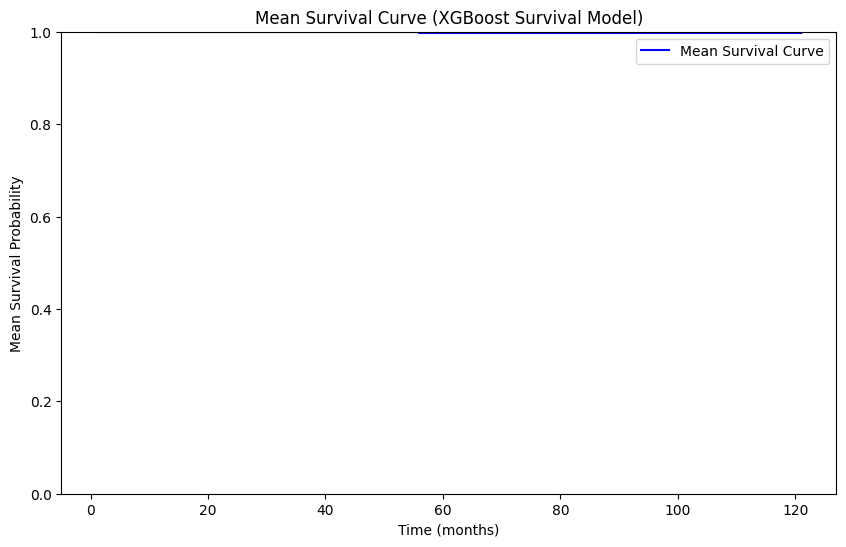

In [ ]:
# Normalize the survival risks (scale them between 0 and 1)
surv_risks_normalized = (surv_risks - np.min(surv_risks)) / (np.max(surv_risks) - np.min(surv_risks))

# Estimate the baseline survival function using Kaplan-Meier on the training data
time, survival_prob = kaplan_meier_estimator(y_train["event"], y_train["time"])

# Calculate the survival probabilities for all individuals
survival_probabilities = predict_survival_probability(surv_risks_normalized, survival_prob, time)

# Calculate the mean survival probability across all individuals
mean_survival_probability = survival_probabilities.mean(axis=0)  # Now (n_time,)

# Plot the mean survival curve
plt.figure(figsize=(10, 6))
plt.step(time, mean_survival_probability, where="post", color="blue", label="Mean Survival Curve")

# Configure the plot
plt.title("Mean Survival Curve (XGBoost Survival Model)")
plt.xlabel("Time (months)")
plt.ylabel("Mean Survival Probability")
plt.ylim([0, 1.0])  # Set y-axis limit to 0-1
plt.legend()
plt.show()

Brier Score at time 12 months: 0.0579
Brier Score at time 36 months: 0.1888
Brier Score at time 60 months: 0.2889
Brier Score at time 84 months: 0.3723
Brier Score at time 120 months: 0.4699

Integrated Brier Score (IBS): 0.2713


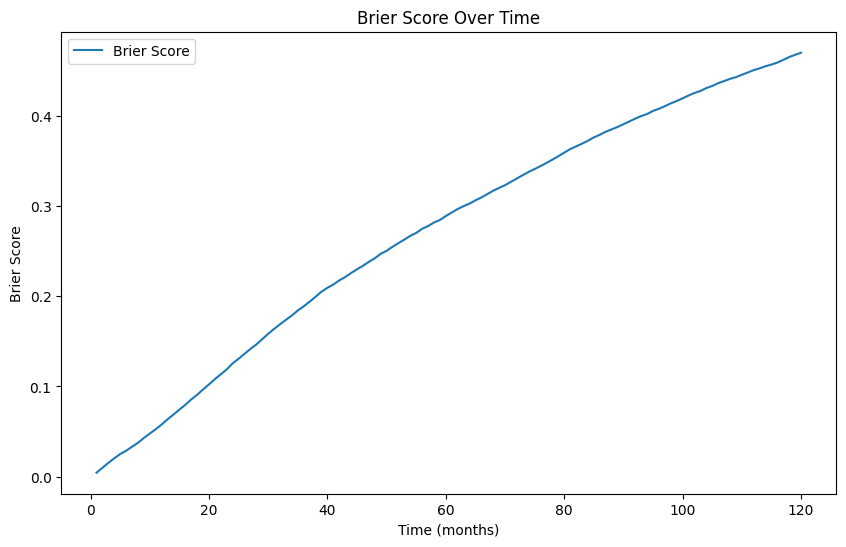

In [ ]:
# Define time points for the calculation (1 to 120 months)
time_points = np.arange(1, 121, 1)  # From 1 to 120 months
specific_time_points = [12, 36, 60, 84, 120]  # Specific time points for analysis

# Ensure alignment of survival probabilities with 'time'
assert survival_probabilities.shape[1] == len(time)

# Adjust the survival probabilities to the desired time points (row by row)
surv_curves = np.array([
    np.interp(time_points, time, survival_probabilities[i, :])  # Interpolate the survival probabilities
    for i in range(survival_probabilities.shape[0])
])

# Calculate the Brier Score at specific time points
brier_scores_specific = []
for t in specific_time_points:
    # Find the index of the closest time point in 'time_points'
    idx = np.abs(time_points - t).argmin()
    prob_surv_t = surv_curves[:, idx]

    # Get the actual observations (whether the event occurred at or after time 't')
    true_values = (y_test['time'] >= t) & (y_test['event'] == 1)

    # Calculate the Brier Score for the time 't'
    brier = brier_score(y_train, y_test, prob_surv_t, [t])
    brier_scores_specific.append(brier[1][0])  # Extract the numeric value

    print(f"Brier Score at time {t} months: {brier[1][0]:.4f}")

# Calculate the Brier Score over time for the Integrated Brier Score (IBS)
brier_scores = brier_score(y_train, y_test, surv_curves, time_points)

# Calculate the Integrated Brier Score (IBS)
time_differences = np.diff(np.hstack([[0], time_points]))  # Time differences between consecutive time points
ibs = np.sum(brier_scores[1] * time_differences) / time_points[-1]  # Calculate the IBS
print(f"\nIntegrated Brier Score (IBS): {ibs:.4f}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1], label="Brier Score")  # Plot Brier Score across time points
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score Over Time")
plt.legend()
plt.show()

In [ ]:
# Best features by permutation importance
calculate_permutation_importance_xgb(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
EC,0.136091,0.002282
ANODIAG,0.044428,0.003083
CATEATEND,0.018616,0.000514
IDADE,0.012924,0.000528
TRATCONS_CAT,0.009164,0.000338
INSTITU,0.006950,0.000486
ESCOLARI,0.006047,0.000326
IBGEATEN,0.005924,0.000573
TOPO,0.004826,0.000374
DIAGTRAT_CAT,0.004759,0.000295


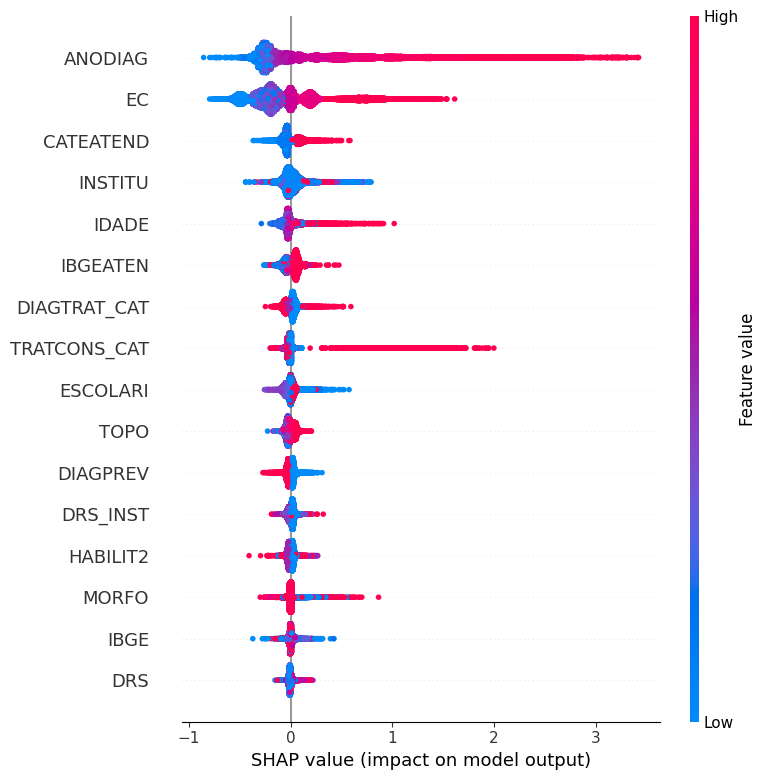

In [ ]:
# Create a SHAP TreeExplainer for the best model
explainer = shap.TreeExplainer(best)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Generate a summary plot to visualize the SHAP values for each feature
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

### **XGBoost - AFT**

#### **Base Model**

In [ ]:
# Define weights (1.0 for events, 0.5 for censored cases)
weights = np.where(y_train['event'], 1.0, 0.5)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

# Creating DMatrix for XGBoost (necessary to define bounds for AFT)
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)

dtest = xgb.DMatrix(X_test)

# Configuration of hyperparameters for the XGBoost Survival AFT model
params = {
    'objective': 'survival:aft',  # Use AFT to model survival analysis
    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT
    'aft_loss_distribution': 'normal',  # Failure time distribution ('normal', 'logistic', etc.)
    'aft_loss_distribution_scale': 1.0,  # Scale of the distribution (adjustable)
    'max_depth': 5,  # Maximum depth of trees
    'seed': seed,  # Seed for reproducibility
}

# Model training
xgb_aft = xgb.train(params, dtrain, num_boost_round=100)

# Predictions and C-Index calculation for the test set
y_pred = xgb_aft.predict(dtest)
c_index_base = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]

# Predictions and C-Index calculation for the training set
y_pred_train = xgb_aft.predict(dtrain)
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Display C-Index results
print(f'C-index Test: {c_index_base}')
print(f'C-index Train: {c_index_train}')

C-index Test: 0.7831264727871521
C-index Train: 0.801647786065886


In [ ]:
# C-Index IPCW (Inverse Probability of Censoring Weight)
surv_risks = xgb_aft.predict(dtest)  # Predict the survival risks for the test set
surv_risks_train = xgb_aft.predict(dtrain)  # Predict the survival risks for the training set

# Calculate the C-Index IPCW for Test and Train data
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -surv_risks)  # Compute the C-Index IPCW for the test data
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -surv_risks_train)  # Compute the C-Index IPCW for the training data

# Display C-Index IPCW for Test and Train data
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')  # Print the C-Index IPCW for the test data
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')  # Print the C-Index IPCW for the training data

C-Index IPCW Test: 0.7556385032296892
C-Index IPCW Train: 0.7736155988579574


#### **Optuna**

In [ ]:
# Optuna number o trials
n_trials = 150

In [ ]:
# Folds for Cross-Validation
kf = KFold(10, shuffle=True, random_state=seed)  # Create 10-fold cross-validation with shuffling

def objective(trial):
    # Define the hyperparameters to be optimized
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # Number of estimators (trees)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, step=0.01),  # Learning rate
        'max_depth': trial.suggest_int('max_depth', 3, 6),  # Maximum depth of trees
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),  # Minimum weight of child nodes
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.05),  # Fraction of data used for training
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.05),  # Fraction of features used per tree
        'reg_alpha': trial.suggest_categorical('reg_alpha', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L1 regularization term
        'reg_lambda': trial.suggest_categorical('reg_lambda', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L2 regularization term
        'aft_loss_distribution': trial.suggest_categorical('aft_loss_distribution', ['normal', 'logistic', 'extreme']),  # AFT Distribution Type
        'aft_loss_distribution_scale': trial.suggest_float('aft_loss_distribution_scale', 0.5, 2.0, step=0.05),  # AFT distribution scale
        'objective': 'survival:aft',  # AFT loss function for survival analysis
        'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
        'random_state': seed,  # Seed for reproducibility
        'n_jobs': -1,  # Use all available cores for training
    }

    fold_c_indices = []  # List to store the C-index values from each fold

    # Loop over the folds in cross-validation
    for train_idx, valid_idx in kf.split(X_train):
        try:
            # Split the data into training and validation sets for the current fold
            X_t, X_v = X_train[train_idx], X_train[valid_idx]  # Split features
            y_t, y_v = y_train[train_idx], y_train[valid_idx]  # Split labels

            # Defining the lower and upper limits for AFT (survival time)
            label_lower_bound = y_t['time']
            label_upper_bound = np.where(y_t['event'], y_t['time'], np.inf)

            # Create DMatrix for training and validation (DMatrix is an optimized data structure for XGBoost)
            dtrain = xgb.DMatrix(X_t, label_lower_bound=label_lower_bound,
                                 label_upper_bound=label_upper_bound,
                                 weight=np.where(y_t['event'], 1.0, 0.5))  # Set event weights

            dvalid = xgb.DMatrix(X_v)  # Validation DMatrix (no labels, predictions will be made)

            # Train the XGBoost model using the specified hyperparameters
            model = xgb.train(param, dtrain, num_boost_round=100, verbose_eval=False)  # Train model with 100 boosting rounds

            # Make predictions on the validation set
            pred_valid = model.predict(dvalid)

            # Calculate the Concordance Index (C-Index) for the validation fold
            c_index = concordance_index_censored(y_v['event'],
                                                 y_v['time'],
                                                 -pred_valid)[0]
            fold_c_indices.append(c_index)  # Append the C-Index for this fold to the list

        except (ValueError, xgb.core.XGBoostError) as e:
            continue  # Next Fold

    # Return the average C-Index
    return np.nanmean(fold_c_indices)  # The objective function returns the mean C-Index from the cross-validation folds

**RandomSampler**

In [ ]:
# Hyperparameter optimization with Optuna - RandomSampler
study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),  # Create a study to maximize the objective function
                            study_name='XGB_RandomSampler')  # Study name

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run the optimization with 'n_trials' trials in parallel

In [ ]:
# Display the best hyperparameters found
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 131, 'learning_rate': 0.13, 'max_depth': 6, 'min_child_weight': 9, 'subsample': 0.95, 'colsample_bytree': 1.0, 'reg_alpha': 0.01, 'reg_lambda': 0.0001, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.35}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.5)  # Assign higher weights to events (1.0 for event and 0.5 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_rand = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_rand.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_rand.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_rand = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_rand_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_rand}')  # C-Index for the test set
print(f'C-Index Train: {c_index_rand_train}')  # C-Index for the training set

C-Index Test: 0.784115440822083
C-Index Train: 0.7992603089690667


**TPESampler**

In [ ]:
# Hyperparameter optimization with Optuna - TPESampler
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),  # Create a study with TPE sampler for optimization
                            study_name='XGB_TPESampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 86, 'learning_rate': 0.18000000000000002, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 1, 'reg_lambda': 0.0001, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.25}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.5)  # Assign higher weights to events (1.0 for event and 0.5 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_tpe = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_tpe.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_tpe.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_tpe = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_tpe_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_tpe}')  # C-Index for the test set
print(f'C-Index Train: {c_index_tpe_train}')  # C-Index for the training set

C-Index Test: 0.7844995688181111
C-Index Train: 0.8033824798389494


**CmaEsSampler**

In [ ]:
# Hyperparameter optimization with Optuna - CmaEsSampler
study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),  # Create a study with CMA-ES sampler for optimization
                            study_name='XGB_CmaEsSampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 82, 'learning_rate': 0.15000000000000002, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 0.8500000000000001, 'colsample_bytree': 0.8500000000000001, 'reg_alpha': 0.001, 'reg_lambda': 0.1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.2000000000000002}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.5)  # Assign higher weights to events (1.0 for event and 0.5 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_cma = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_cma.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_cma.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_cma = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_cma_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_cma}')  # C-Index for the test set
print(f'C-Index Train: {c_index_cma_train}')  # C-Index for the training set

C-Index Test: 0.7837661113587593
C-Index Train: 0.8010332104012601


#### **Best XGBoost Model**

In [ ]:
# Best XGBoost model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for each model
models = [xgb_aft, xgb_rand, xgb_tpe, xgb_cma]  # List of the trained models

# Find the model with the highest C-index
id_best_score = scores.index(max(scores))  # Get the index of the model with the best score
best = models[id_best_score]  # Select the best model based on the highest C-index

print(best)  # Display the best model

In [ ]:
# Make predictions on the validation and training sets
y_pred = best.predict(dtest)  # Predictions on the test set
y_pred_train = best.predict(dtrain)  # Predictions on the training set

# Calculate the C-Index for the test and training sets
final_c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for the test set
final_c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for the training set

print('C-Index')  # Print label for C-Index
print(f'> Test: {final_c_index}')  # Print C-Index for the test set
print(f'> Train: {final_c_index_train}')  # Print C-Index for the training set

# Calculate the C-Index IPCW (Inverse Probability of Censoring Weight)
surv_risks = best.predict(dtest)  # Survival risks for the test set
surv_risks_train = best.predict(dtrain)  # Survival risks for the training set

c_index_ipcw = concordance_index_ipcw(y_train, y_test, -surv_risks)  # C-Index IPCW for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -surv_risks_train)  # C-Index IPCW for the training set

print('\nC-Index IPCW')  # Print label for C-Index IPCW
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7844995688181111
> Train: 0.8033824798389494

C-Index IPCW
> Test: 0.757043300716891
> Train: 0.7757009566575918


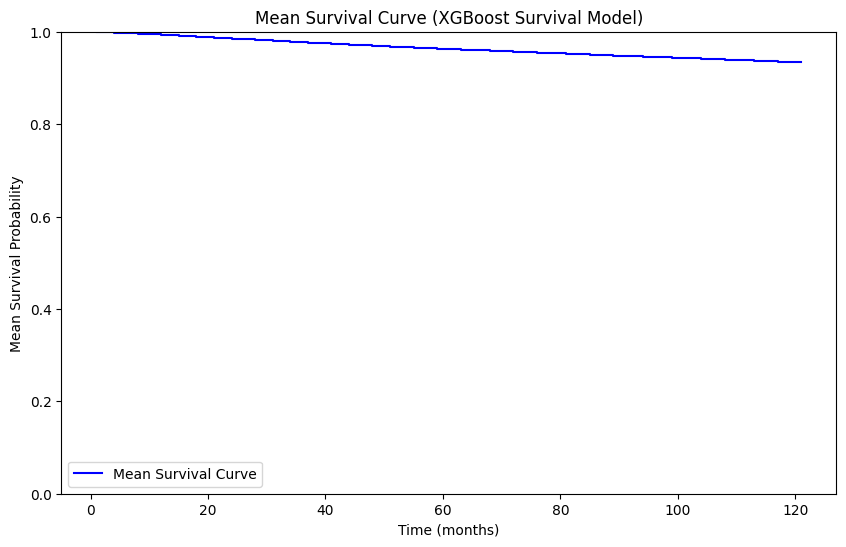

In [ ]:
# Normalize the survival risks (scale them between 0 and 1)
surv_risks_normalized = (surv_risks - np.min(surv_risks)) / (np.max(surv_risks) - np.min(surv_risks))

# Estimate the baseline survival function using Kaplan-Meier on the training data
time, survival_prob = kaplan_meier_estimator(y_train["event"], y_train["time"])

# Calculate the survival probabilities for all individuals
survival_probabilities = predict_survival_probability(surv_risks_normalized, survival_prob, time)

# Calculate the mean survival probability across all individuals
mean_survival_probability = survival_probabilities.mean(axis=0)  # Now (n_time,)

# Plot the mean survival curve
plt.figure(figsize=(10, 6))
plt.step(time, mean_survival_probability, where="post", color="blue", label="Mean Survival Curve")

# Configure the plot
plt.title("Mean Survival Curve (XGBoost Survival Model)")
plt.xlabel("Time (months)")
plt.ylabel("Mean Survival Probability")
plt.ylim([0, 1.0])  # Set y-axis limit to 0-1
plt.legend()
plt.show()

Brier Score at time 12 months: 0.0579
Brier Score at time 36 months: 0.1868
Brier Score at time 60 months: 0.2817

Integrated Brier Score (IBS): 0.1525


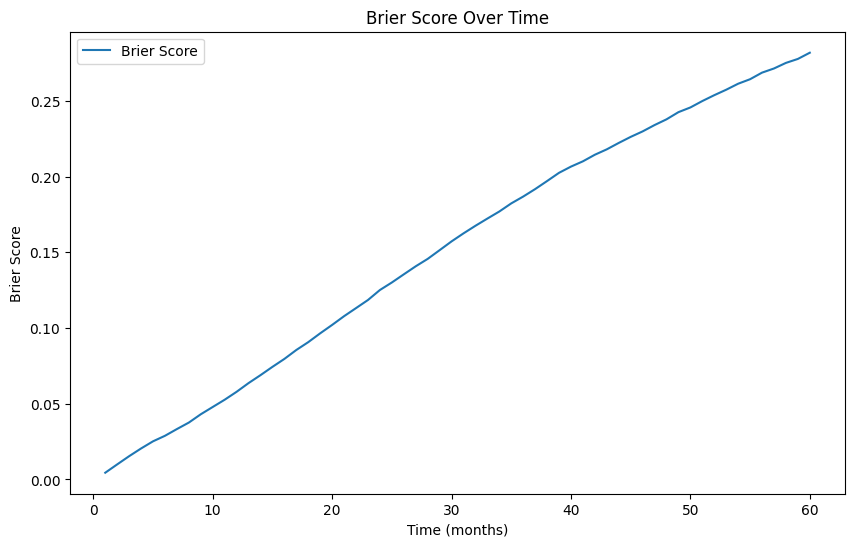

In [ ]:
# Define time points for the calculation (1 to 60 months)
time_points = np.arange(1, 61, 1)  # From 1 to 60 months
specific_time_points = [12, 36, 60]  # Specific time points for analysis

# Ensure alignment of survival probabilities with 'time'
assert survival_probabilities.shape[1] == len(time)

# Adjust the survival probabilities to the desired time points (row by row)
surv_curves = np.array([
    np.interp(time_points, time, survival_probabilities[i, :])  # Interpolate the survival probabilities
    for i in range(survival_probabilities.shape[0])
])

# Calculate the Brier Score at specific time points
brier_scores_specific = []
for t in specific_time_points:
    # Find the index of the closest time point in 'time_points'
    idx = np.abs(time_points - t).argmin()
    prob_surv_t = surv_curves[:, idx]

    # Get the actual observations (whether the event occurred at or after time 't')
    true_values = (y_test['time'] >= t) & (y_test['event'] == 1)

    # Calculate the Brier Score for the time 't'
    brier = brier_score(y_train, y_test, prob_surv_t, [t])
    brier_scores_specific.append(brier[1][0])  # Extract the numeric value

    print(f"Brier Score at time {t} months: {brier[1][0]:.4f}")

# Calculate the Brier Score over time for the Integrated Brier Score (IBS)
brier_scores = brier_score(y_train, y_test, surv_curves, time_points)

# Calculate the Integrated Brier Score (IBS)
time_differences = np.diff(np.hstack([[0], time_points]))  # Time differences between consecutive time points
ibs = np.sum(brier_scores[1] * time_differences) / time_points[-1]  # Calculate the IBS
print(f"\nIntegrated Brier Score (IBS): {ibs:.4f}")

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))
plt.plot(time_points, brier_scores[1], label="Brier Score")  # Plot Brier Score across time points
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")
plt.title("Brier Score Over Time")
plt.legend()
plt.show()

In [ ]:
# Best features by permutation importance
calculate_permutation_importance_xgb(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
IBGE,-0.000460,0.000206
HABILIT2,-0.001343,0.000161
DRS_INST,-0.001565,0.000278
DRS,-0.001818,0.000131
DIAGPREV,-0.002172,0.000222
MORFO,-0.002482,0.000327
TOPO,-0.002834,0.000378
DIAGTRAT_CAT,-0.003086,0.000396
ESCOLARI,-0.003879,0.000341
TRATCONS_CAT,-0.004448,0.000341


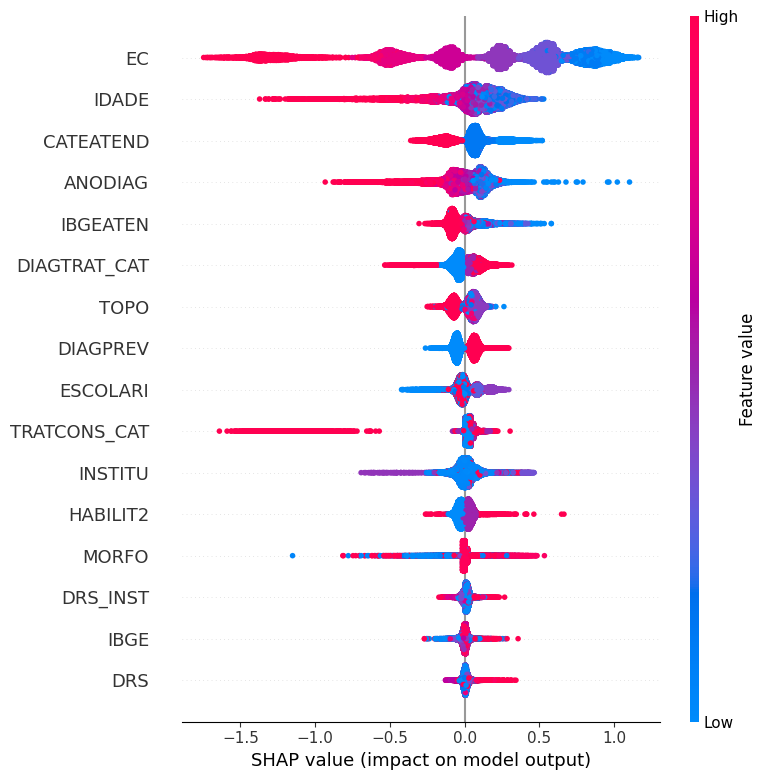

In [ ]:
# Create a SHAP TreeExplainer for the best model
explainer = shap.TreeExplainer(best)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Generate a summary plot to visualize the SHAP values for each feature
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

### **LightGBM**

#### **Base Model**

In [ ]:
# LightGBM Model
dtrain = lgb.Dataset(X_train, label=y_train['time'],
                     weight=np.where(y_train['event'], 1.0, 0.15))  # Create a LightGBM dataset with event weights

# Define model parameters
params = {
    'objective': 'regression',  # LightGBM does not have direct survival support, using regression as a proxy
    'metric': 'rmse',           # Metric for monitoring (not used for survival analysis)
    'max_depth': 6,             # Maximum depth of trees
    'seed': seed,               # Set random seed for reproducibility
    'verbose': -1,              # Suppress output during training
    'n_jobs': -1                # Use all CPU cores for training
}

# Train the model
lgbm = lgb.train(params, dtrain, num_boost_round=100)  # Train the LightGBM model with 100 boosting rounds

# Make predictions (risk scores)
y_pred = lgbm.predict(X_test)  # Predict risk scores on the test data

# Evaluate the model using the C-Index (Test data)
c_index_base = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # Calculate C-Index for test data

# Evaluate the model using the C-Index (Train data)
y_pred_train = lgbm.predict(X_train)  # Predict risk scores on the training data
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # Calculate C-Index for training data

# Display the results
print(f'C-index Test: {c_index_base}')  # Print the C-Index for test data
print(f'C-index Train: {c_index_train}')  # Print the C-Index for train data

C-index Test: 0.7094950461948621
C-index Train: 0.7174961194484221


In [ ]:
# C-Index IPCW (Inverse Probability of Censoring Weight)
surv_risks = lgbm.predict(X_test)  # Predict survival risks for the test data
surv_risks_train = lgbm.predict(X_train)  # Predict survival risks for the training data

# Calculate the C-Index using IPCW for test data
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -surv_risks)  # Evaluate the concordance index for test data

# Calculate the C-Index using IPCW for training data
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -surv_risks_train)  # Evaluate the concordance index for training data

# Display the results for C-Index IPCW
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')  # Print the IPCW C-Index for test data
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')  # Print the IPCW C-Index for train data

C-Index IPCW Test: 0.6962213264676903
C-Index IPCW Train: 0.7023387716312414


#### **Optuna**

In [ ]:
# Optuna number of trials
n_trials = 150

In [ ]:
# Folds for cross-validation
kf = KFold(10, shuffle=True, random_state=seed)  # Split the data into 10 folds, shuffle data and set a random seed

# Objective function for hyperparameter optimization
def objective(trial):
    # Define the hyperparameters to be optimized
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # Number of trees in the model
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, step=0.01),  # Learning rate for boosting
        'max_depth': trial.suggest_int('max_depth', 3, 8),  # Maximum depth of the trees
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),  # Number of leaves in each tree
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 20),  # Minimum samples for each child node
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.05),  # Subsample ratio for training
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.05),  # Column sampling ratio for each tree
        'reg_alpha': trial.suggest_categorical('reg_alpha', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10.0]),  # L1 regularization term
        'reg_lambda': trial.suggest_categorical('reg_lambda', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10.0]),  # L2 regularization term
        'objective': 'regression',  # Set objective to regression (using Cox regression as a proxy)
        'metric': 'rmse',  # Metric for evaluation (Root Mean Squared Error)
        'seed': seed,  # Random seed
        'verbose': -1,  # Suppress output during training
        'n_jobs': -1  # Use all available CPU cores for parallel computation
    }

    c_index_list = []  # Initialize an empty list to store the C-Index scores for each fold

    # Loop through the folds for cross-validation
    for train_idx, valid_idx in kf.split(X_train):
        # Split the data into training and validation sets based on the current fold
        X_t, X_v = X_train[train_idx], X_train[valid_idx]  # Training and validation features
        y_t, y_v = y_train[train_idx], y_train[valid_idx]  # Training and validation target labels

        # Create DMatrix for training data, using weights based on event occurrence
        dtrain = lgb.Dataset(X_t, label=y_t['time'], weight=np.where(y_t['event'], 1.0, 0.15))

        # Train the model using the current hyperparameters
        model = lgb.train(param, dtrain, num_boost_round=100)

        # Make predictions on the validation set
        pred_valid = model.predict(X_v)

        # Calculate the Concordance Index for the validation fold
        c_index = concordance_index_censored(y_v['event'], y_v['time'], -pred_valid)[0]
        c_index_list.append(c_index)  # Append the C-Index score to the list

    # Return the mean C-Index across all folds
    return np.mean(c_index_list)

**RandomSampler**

In [ ]:
# Hyperparameter optimization with Optuna - RandomSampler
study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),  # Create an Optuna study with a random sampler for optimization
                            study_name='LGBM_RandomSampler')  # Name the study for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Optimize the objective function using a random sampler

In [ ]:
# Display the best hyperparameters found during the optimization process
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 146, 'learning_rate': 0.09999999999999999, 'max_depth': 7, 'num_leaves': 73, 'min_child_samples': 12, 'subsample': 0.6, 'colsample_bytree': 0.55, 'reg_alpha': 0.01, 'reg_lambda': 0.1}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.15)  # Assign weights based on event occurrence (1.0 for events, 0.15 for censored data)

# Update the best parameters with the required model settings
best_params = study.best_params
best_params.update({'objective': 'regression',  # Use regression (Cox model) for survival analysis
                    'metric': 'rmse',  # Metric for monitoring performance (Root Mean Squared Error)
                    'seed': seed,  # Set the random seed for reproducibility
                    'verbose': -1,  # Suppress output during training
                    'n_jobs': -1})  # Use all available CPU cores for parallel computation

# Create the LightGBM dataset using the training data and weights
dtrain = lgb.Dataset(X_train, label=y_train['time'], weight=weights)
# dtest = xgb.DMatrix(X_test)  # You could use this for testing if needed, but it's not used here

# Train the LightGBM model with the best parameters found by Optuna
lgbm_rand = lgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the validation and training sets
y_pred = lgbm_rand.predict(X_test)  # Predictions for the test set
y_pred_train = lgbm_rand.predict(X_train)  # Predictions for the training set

# Calculate the Concordance Index (C-Index) for the test set
c_index_rand = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_rand_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Display the C-Index for both test and training sets
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {c_index_rand_train}')

C-Index Test: 0.7132608872666698
C-Index Train: 0.7333826019229964


**TPESampler**

In [ ]:
# Hyperparameter optimization with Optuna - TPESampler
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),  # Create an Optuna study using the TPE sampler for optimization
                            study_name='LGBM_TPESampler')  # Name the study for easier identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Optimize the objective function using TPE with specified trials and parallel jobs

In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 142, 'learning_rate': 0.09999999999999999, 'max_depth': 7, 'num_leaves': 97, 'min_child_samples': 8, 'subsample': 0.65, 'colsample_bytree': 0.5, 'reg_alpha': 0.0001, 'reg_lambda': 10.0}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.15)  # Assign weights based on event occurrence (1.0 for events, 0.15 for censored data)

# Update the best parameters with the necessary model settings
best_params = study.best_params
best_params.update({'objective': 'regression',  # Using Cox regression for survival analysis
                    'metric': 'rmse',  # Root Mean Squared Error metric for monitoring performance
                    'seed': seed,  # Set the random seed for reproducibility
                    'verbose': -1,  # Suppress output during training
                    'n_jobs': -1})  # Use all available CPU cores for parallel computation

# Create the LightGBM dataset using the training data and weights
dtrain = lgb.Dataset(X_train, label=y_train['time'], weight=weights)
# dtest = xgb.DMatrix(X_test)  # You could use this for testing, but it's not utilized in the current context

# Train the LightGBM model with the best parameters found by Optuna
lgbm_tpe = lgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on both the validation and training sets
y_pred = lgbm_tpe.predict(X_test)  # Predictions for the test set
y_pred_train = lgbm_tpe.predict(X_train)  # Predictions for the training set

# Calculate the Concordance Index (C-Index) for the test set
c_index_tpe = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_tpe_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Display the C-Index for both the test and training sets
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {c_index_tpe_train}')

C-Index Test: 0.7126918827524884
C-Index Train: 0.7318281024651898


**CmaEsSampler**

In [ ]:
# Hyperparameter optimization with Optuna - CmaEsSampler
study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),  # Create an Optuna study using the CMA-ES sampler for optimization
                            study_name='LGBM_CmaEsSampler')  # Name the study for easier identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Optimize the objective function using CMA-ES with specified trials and parallel jobs

In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 130, 'learning_rate': 0.09, 'max_depth': 7, 'num_leaves': 83, 'min_child_samples': 13, 'subsample': 0.75, 'colsample_bytree': 0.65, 'reg_alpha': 0.001, 'reg_lambda': 0.001}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.15)  # Assign weights based on event occurrence (1.0 for events, 0.15 for censored data)

# Update the best parameters with the necessary model settings
# best_params = study.best_params
best_params.update({'objective': 'regression',  # Using Cox regression for survival analysis
                    'metric': 'rmse',  # Root Mean Squared Error metric for monitoring performance
                    'seed': seed,  # Set the random seed for reproducibility
                    'verbose': -1,  # Suppress output during training
                    'n_jobs': -1})  # Use all available CPU cores for parallel computation

# Create the LightGBM dataset using the training data and weights
dtrain = lgb.Dataset(X_train, label=y_train['time'], weight=weights)
# dtest = xgb.DMatrix(X_test)  # You could use this for testing, but it's not utilized in the current context

# Train the LightGBM model with the best parameters found by Optuna
lgbm_cma = lgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on both the validation and training sets
y_pred = lgbm_cma.predict(X_test)  # Predictions for the test set
y_pred_train = lgbm_cma.predict(X_train)  # Predictions for the training set

# Calculate the Concordance Index (C-Index) for the test set
c_index_cma = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_cma_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Display the C-Index for both the test and training sets
print(f'C-Index Test: {c_index_cma}')
print(f'C-Index Train: {c_index_cma_train}')

C-Index Test: 0.7126918827524884
C-Index Train: 0.7318281024651898


#### **Best LightGBM Model**

In [ ]:
# Best LightGBM Model Selection
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-Index scores for each model (base, random, TPE, CMA-ES)
models = [lgbm, lgbm_rand, lgbm_tpe, lgbm_cma]  # List of LightGBM models corresponding to each hyperparameter optimization approach

# Identify the model with the highest C-Index score
id_best_score = scores.index(max(scores))  # Find the index of the highest C-Index score
best = models[id_best_score]  # Select the model corresponding to the best score

# Display the best model
print(best)

In [ ]:
# Make predictions on the validation and training sets
y_pred = best.predict(X_test)  # Predict survival risks on the test set using the best model
y_pred_train = best.predict(X_train)  # Predict survival risks on the training set using the best model

# Calculate C-Index for the test set
final_c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # Compute the concordance index for the test set
final_c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # Compute the concordance index for the training set

# Display C-Index results
print('C-Index')
print(f'> Test: {final_c_index}')  # Print the C-Index for the test set
print(f'> Train: {final_c_index_train}')  # Print the C-Index for the training set

# Calculate the C-Index with Inverse Probability of Censoring Weighting (IPCW)
surv_risks = best.predict(X_test)  # Get the survival risks (predictions) for the test set
surv_risks_train = best.predict(X_train)  # Get the survival risks (predictions) for the training set

# Calculate IPCW C-Index
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -surv_risks)  # Compute IPCW C-Index for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -surv_risks_train)  # Compute IPCW C-Index for the training set

# Display IPCW C-Index results
print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7132608872666698
> Train: 0.7333826019229964

C-Index IPCW
> Test: 0.6999553106912016
> Train: 0.7131837457961535


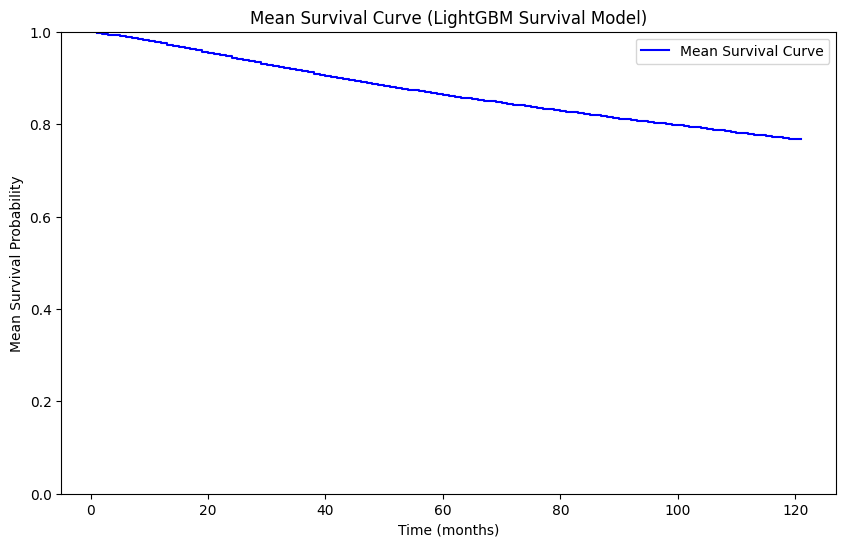

In [ ]:
# Normalize the survival risks (scale them between 0 and 1)
surv_risks_normalized = (surv_risks - np.min(surv_risks)) / (np.max(surv_risks) - np.min(surv_risks))

# Estimate the baseline survival function using Kaplan-Meier on the training data
time, survival_prob = kaplan_meier_estimator(y_train["event"], y_train["time"])

# Calculate the survival probabilities for all individuals
survival_probabilities = predict_survival_probability(surv_risks_normalized, survival_prob, time)

# Calculate the mean survival probability across all individuals
mean_survival_probability = survival_probabilities.mean(axis=0)  # Now (n_time,)

# Plot the mean survival curve
plt.figure(figsize=(10, 6))
plt.step(time, mean_survival_probability, where="post", color="blue", label="Mean Survival Curve")

# Configure the plot
plt.title("Mean Survival Curve (LightGBM Survival Model)")
plt.xlabel("Time (months)")
plt.ylabel("Mean Survival Probability")
plt.ylim([0, 1.0])  # Set y-axis limit to 0-1
plt.legend()
plt.show()

Brier Score at 12 months: 0.0569
Brier Score at 36 months: 0.1728
Brier Score at 60 months: 0.2461
Brier Score at 84 months: 0.2952
Brier Score at 120 months: 0.3334

Integrated Brier Score (IBS): 0.2198


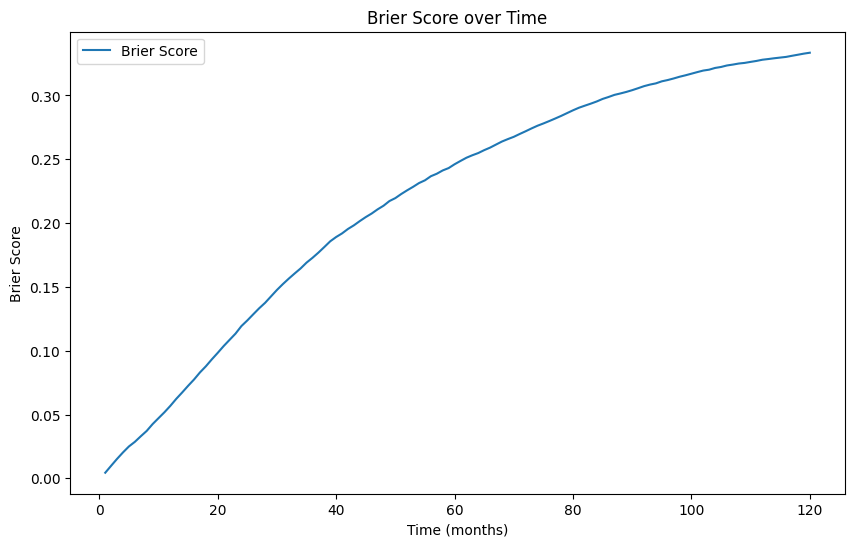

In [ ]:
# Define the time points for calculation, from 1 to 120 months
time_points = np.arange(1, 121, 1)  # From 1 to 120 months
specific_time_points = [12, 36, 60, 84, 120]  # Specific time points for analysis

# Ensure the alignment of survival_probabilities with 'time'
assert survival_probabilities.shape[1] == len(time)  # Check that the number of time points matches

# Interpolate the survival probabilities to match the desired time points (line by line)
surv_curves = np.array([
    np.interp(time_points, time, survival_probabilities[i, :])  # Interpolate survival probabilities for each individual
    for i in range(survival_probabilities.shape[0])  # Loop over each individual
])

# Calculate the Brier Score at specific time points
brier_scores_specific = []
for t in specific_time_points:
    # Find the closest time index in 'time_points'
    idx = np.abs(time_points - t).argmin()
    prob_surv_t = surv_curves[:, idx]  # Get the survival probabilities at the specified time point

    # Obtain the true values based on the actual event and time
    true_values = (y_test['time'] >= t) & (y_test['event'] == 1)

    # Calculate the Brier Score for the given time point t
    brier = brier_score(y_train, y_test, prob_surv_t, [t])
    brier_scores_specific.append(brier[1][0])  # Extract the numerical Brier Score value

    print(f"Brier Score at {t} months: {brier[1][0]:.4f}")  # Print the Brier Score at the specific time point

# Calculate the Brier Score over the entire time range for the Integrated Brier Score (IBS)
brier_scores = brier_score(y_train, y_test, surv_curves, time_points)

# Calculate the Integrated Brier Score (IBS) by summing the weighted Brier Scores over time
time_differences = np.diff(np.hstack([[0], time_points]))  # Compute time differences between consecutive time points
ibs = np.sum(brier_scores[1] * time_differences) / time_points[-1]  # Calculate IBS
print(f"\nIntegrated Brier Score (IBS): {ibs:.4f}")  # Print the Integrated Brier Score

# Plot the Brier Score over time
plt.figure(figsize=(10, 6))  # Create a figure with the specified size
plt.plot(time_points, brier_scores[1], label="Brier Score")  # Plot Brier Score over time
plt.xlabel("Time (months)")  # Label the x-axis
plt.ylabel("Brier Score")  # Label the y-axis
plt.title("Brier Score over Time")  # Set the plot title
plt.legend()  # Add a legend to the plot
plt.show()  # Display the plot

In [ ]:
# Best features by permutation importance
calculate_permutation_importance_lgbm(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
EC,0.146560,0.002295
ANODIAG,0.044929,0.002798
CATEATEND,0.021943,0.000810
IDADE,0.013458,0.000618
DIAGTRAT_CAT,0.007451,0.000353
INSTITU,0.006229,0.000515
ESCOLARI,0.005812,0.000273
TRATCONS_CAT,0.005548,0.000302
TOPO,0.005117,0.000406
DRS,0.003048,0.000214


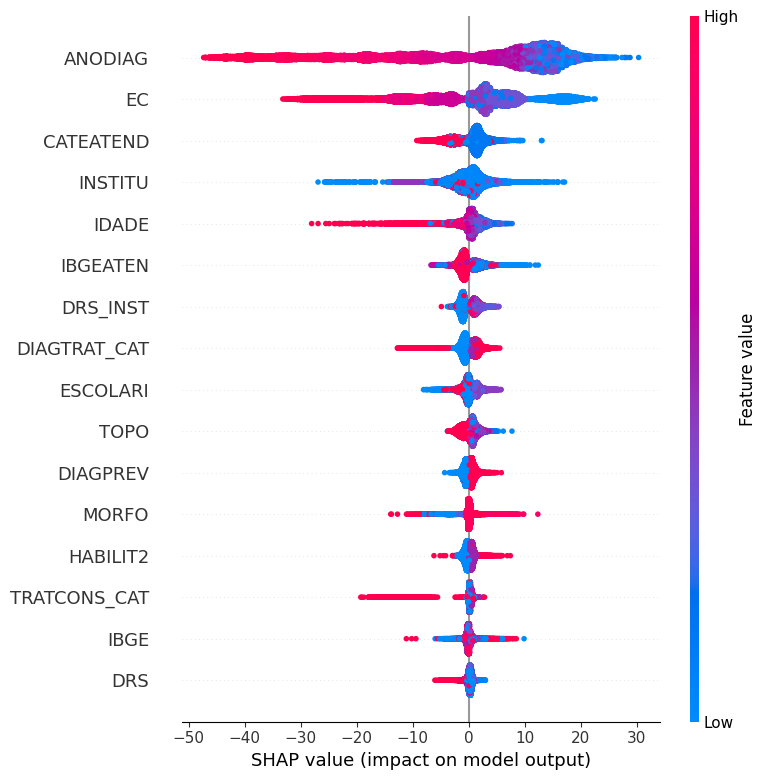

In [ ]:
# Create a SHAP TreeExplainer for the best model
explainer = shap.TreeExplainer(best)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Generate a summary plot to visualize the SHAP values for each feature
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)